# METS-R SIM Security Examples

This notebook is an opt-in cyber-range workflow for METS-R SIM. It demonstrates how to reproduce, measure, and reason about five local simulator attacks:

1. Basic Safety Message replay and spoofing.
2. Unauthorized maneuver commands.
3. Adversarial ride-hailing booking and cancellation.
4. Route-guidance edge-weight spoofing.
5. Charging-price spoofing.

Run these examples only against simulation instances that you control. The cells intentionally call `METSRClient` methods directly so the notebook teaches the API request and response patterns without wrapping them in tutorial abstractions.

## Setup

Run this first. The attack cells start Docker containers, Kafka, and/or METS-R SIM instances as needed, so execute them in order when you want the full workflow, or run an individual attack cell when you only need that scenario.

In [3]:
import os
import sys
import time
import math
import shutil
import subprocess
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if os.path.basename(os.getcwd()) == "tutorials":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from utils.util import read_run_config, prepare_sim_dirs, run_simulation_in_docker
from clients.METSRClient import METSRClient

try:
    from clients.KafkaDataProcessor import (
        KafkaDataProcessor,
        bsm_core_latitude_degrees,
        bsm_core_longitude_degrees,
        bsm_core_speed_mps,
    )
    from clients.KafkaDataSender import KafkaDataSender
    KAFKA_AVAILABLE = True
except ImportError as exc:
    KAFKA_AVAILABLE = False
    KAFKA_IMPORT_ERROR = exc

from utils.util import clear_all
clear_all() # clear all mets-r related processes, if any


def bsm_lat_lon_degrees(record):
    return bsm_core_latitude_degrees(record), bsm_core_longitude_degrees(record)


def bsm_speed_mps(record):
    speed = bsm_core_speed_mps(record)
    if speed is not None:
        return float(speed)
    return float(record.get("velocity", record.get("speed", 0.0)) or 0.0)


def numeric_or_none(value):
    try:
        if value is None:
            return None
        number = float(value)
    except (TypeError, ValueError):
        return None
    return number if math.isfinite(number) else None


def nested_get(record, *keys):
    current = record
    for key in keys:
        if not isinstance(current, dict):
            return None
        current = current.get(key)
    return current


def bsm_local_xy(record):
    for x_key, y_key in (("x", "y"), ("local_x", "local_y"), ("x_m", "y_m")):
        x = numeric_or_none(record.get(x_key))
        y = numeric_or_none(record.get(y_key))
        if x is not None and y is not None:
            return x, y
    for path in (
        ("operationalData", "localPositionM"),
        ("operational_data", "localPositionM"),
        ("messaging_layer", "probe_data"),
    ):
        position = nested_get(record, *path)
        if isinstance(position, dict):
            x = numeric_or_none(position.get("x"))
            y = numeric_or_none(position.get("y"))
            if x is not None and y is not None:
                return x, y
    return None, None


def bsm_distance_m(left, right):
    left_x, left_y = bsm_local_xy(left)
    right_x, right_y = bsm_local_xy(right)
    if None not in (left_x, left_y, right_x, right_y):
        return math.hypot(right_x - left_x, right_y - left_y)

    left_lat, left_lon = bsm_lat_lon_degrees(left)
    right_lat, right_lon = bsm_lat_lon_degrees(right)
    if None in (left_lat, left_lon, right_lat, right_lon):
        return None
    dx = math.radians(float(right_lon) - float(left_lon)) * math.cos(
        math.radians((float(right_lat) + float(left_lat)) / 2.0)
    )
    dy = math.radians(float(right_lat) - float(left_lat))
    return 6371000.0 * math.sqrt(dx * dx + dy * dy)


def same_vehicle_id(value, expected):
    try:
        return int(value) == int(expected)
    except (TypeError, ValueError):
        return str(value) == str(expected)


def poll_bsm_records(processor, target_vid=None, timeout_ms=None, max_polls=2):
    if timeout_ms is None:
        timeout_ms = processor.poll_timeout_ms
    records = []
    for _ in range(max_polls):
        batch = processor.process_bsm(timeout_ms=timeout_ms) or []
        records.extend(batch)
        if target_vid is None or any(same_vehicle_id(record.get("vid"), target_vid) for record in records):
            break
    return records


def vehicle_has_road(record):
    return bool(record) and any(record.get(key) is not None for key in ("road", "road_id", "roadID"))


def first_vehicle_record(response):
    records = response.get("DATA", []) if isinstance(response, dict) else []
    return records[0] if records else None


def wait_until_vehicle_on_road(client, vid, private_veh=True, max_ticks=240, label="Vehicle"):
    last_record = None
    for _ in range(max_ticks):
        client.tick(1)
        last_record = first_vehicle_record(client.query_vehicle(vid, private_veh=private_veh))
        if vehicle_has_road(last_record):
            return last_record
    raise RuntimeError(
        f"{label} did not enter the road network after {max_ticks} ticks. "
        f"Last query record: {last_record!r}"
    )


def kafka_bootstrap_servers(config):
    return getattr(
        config,
        "kafka_bootstrap_servers",
        getattr(config, "kafka_bootstrap_server", "localhost:29092"),
    )


def docker_compose_command():
    if shutil.which("docker-compose"):
        return ["docker-compose"]
    if shutil.which("docker"):
        return ["docker", "compose"]
    raise RuntimeError("Docker Compose was not found. Install Docker Desktop or start Kafka manually on localhost:29092.")


def run_docker_compose(*args):
    subprocess.run(docker_compose_command() + list(args), cwd="docker", check=True)


def wait_for_kafka(bootstrap_servers="localhost:29092", timeout_s=90):
    from kafka import KafkaAdminClient

    deadline = time.time() + timeout_s
    last_error = None
    while time.time() < deadline:
        try:
            admin = KafkaAdminClient(
                bootstrap_servers=bootstrap_servers,
                request_timeout_ms=3000,
                api_version_auto_timeout_ms=3000,
            )
            admin.close()
            return
        except Exception as exc:
            last_error = exc
            time.sleep(2)
    raise RuntimeError(
        f"Kafka broker at {bootstrap_servers!r} did not become ready within {timeout_s} seconds. "
        "Check Docker Desktop and `docker compose ps`, or start a Kafka broker that advertises localhost:29092. "
        f"Last error: {last_error!r}"
    ) from last_error

print("Working directory:", os.getcwd())


No registered METS-R client helper servers found.
No process-local visualization file servers found.
stopped: bb8f06b34d0d image=ennuilei/mets-r_sim name=quirky_haibt
Working directory: c:\Users\ALei\Documents\GitHub\METS-R_HPC


## Running Pattern

Each attack cell follows the same direct pattern: read a config, adjust the few fields the experiment needs, prepare simulation folders, start METS-R SIM, create a `METSRClient`, call the relevant client APIs, then terminate the client in `finally`.

# Attack 1: Basic Safety Message Replay

This follows the original cyber-range scenario: first record BSMs from a deliberately slow connected vehicle, then replay those historical messages into a fresh run. The ego vehicle reads the Kafka BSM stream, computes a simple car-following acceleration from the perceived nearby vehicle, and sends that acceleration with `client.control_vehicle`. The attack is visible by comparing normal and replayed speed/acceleration traces and asking when the disturbance starts to dissipate.

In [ ]:
bsm_replay_result = None

if not KAFKA_AVAILABLE:
    raise RuntimeError(f"Kafka tooling is unavailable: {KAFKA_IMPORT_ERROR}")

bsm_client = None
processor = None
sender = None
kafka_started = False
cwd = os.getcwd()

try:
    bsm_config = read_run_config("configs/run_cosim_CARLAT7.json")
    bsm_config.verbose = False
    bootstrap_servers = kafka_bootstrap_servers(bsm_config)
    run_docker_compose("up", "-d")
    kafka_started = True
    wait_for_kafka(bootstrap_servers)

    bsm_sim_dirs = prepare_sim_dirs(bsm_config)
    run_simulation_in_docker(bsm_config)

    bsm_client = METSRClient(
        host=bsm_config.metsr_host,
        sim_folder=bsm_sim_dirs[0],
        port=bsm_config.ports[0] if hasattr(bsm_config, "ports") else bsm_config.metsr_port,
        timeout=600,
    )
    processor = KafkaDataProcessor(bsm_config)
    sender = KafkaDataSender(bsm_config)

    processor.clear()

    # Phase 1: create a very slow connected vehicle and record its BSM stream.
    replay_source_vid = 0
    ego_vid = 1
    replay_origin = "-20"
    replay_destination = "-20"
    record_ticks = 3000
    run_ticks = 6000
    replay_offset_ticks = 10

    bsm_client.generate_trip_between_roads(replay_source_vid, replay_origin, replay_destination)
    bsm_client.update_vehicle_sensor_type(replay_source_vid, 1, True)

    wait_until_vehicle_on_road(
        bsm_client,
        replay_source_vid,
        private_veh=True,
        label="Replay-source vehicle",
    )

    replay_data = []
    replay_counts = []
    for _ in range(record_ticks):
        source_state = bsm_client.query_vehicle(replay_source_vid, private_veh=True).get("DATA", [])[0]
        if source_state.get("speed", 0.0) > 1.0:
            bsm_client.control_vehicle(replay_source_vid, -0.5, private_veh=True)

        bsm_client.tick(1)
        batch = poll_bsm_records(processor, target_vid=replay_source_vid)
        replay_data.append(batch)
        replay_counts.append(len(batch))

    # Phase 2: replay the stale BSMs into an ego controller and record the attacked trace.
    # Start a fresh simulator instead of resetting in-place; this avoids a transient
    # STEP/KO race immediately after CTRL_reset and gives the attacked run its own output folder.
    processor.clear()
    bsm_client.terminate()
    bsm_client = None
    bsm_sim_dirs = prepare_sim_dirs(bsm_config)
    run_simulation_in_docker(bsm_config)
    bsm_client = METSRClient(
        host=bsm_config.metsr_host,
        sim_folder=bsm_sim_dirs[0],
        port=bsm_config.ports[0] if hasattr(bsm_config, "ports") else bsm_config.metsr_port,
        timeout=600,
    )
    bsm_client.tick(10, wait_forever=True)
    bsm_client.generate_trip_between_roads(ego_vid, replay_origin, replay_destination)
    bsm_client.update_vehicle_sensor_type(ego_vid, 1, True)

    wait_until_vehicle_on_road(
        bsm_client,
        ego_vid,
        private_veh=True,
        label="Attacked ego vehicle",
    )

    target_velocity = 10.0
    max_acceleration = 2.0
    kp = 0.5
    min_gap_m = 5.0
    attacked_speed = []
    attacked_acc = []
    attacked_injections = []

    for tick_index in range(run_ticks):
        bsm_client.tick(1)

        replay_messages = []
        replay_index = tick_index + replay_offset_ticks
        if replay_index < len(replay_data):
            for replay_record in replay_data[replay_index]:
                replay_message = dict(replay_record)
                replay_message["attack_label"] = "bsm_replay"
                replay_messages.append(replay_message)
        injected = len(replay_messages)
        if replay_messages:
            sender.send("bsm", replay_messages)

        data_stream = poll_bsm_records(processor, target_vid=ego_vid)
        ego_message = next((record for record in data_stream if same_vehicle_id(record.get("vid"), ego_vid)), None)
        command_acc = -0.01

        if ego_message is not None:
            ego_speed = bsm_speed_mps(ego_message)
            front_candidates = []

            for record in data_stream:
                if same_vehicle_id(record.get("vid"), ego_vid):
                    continue
                distance_m = bsm_distance_m(ego_message, record)
                if distance_m is None:
                    continue
                front_speed = bsm_speed_mps(record)
                front_candidates.append((distance_m, front_speed))

            if front_candidates:
                front_distance, front_speed = min(front_candidates, key=lambda item: item[0])
                relative_speed = ego_speed - front_speed
                if front_distance < min_gap_m:
                    command_acc = -max_acceleration
                elif front_distance < 2 * min_gap_m and relative_speed > 0:
                    command_acc = -min(max_acceleration, relative_speed ** 2 / (2 * max(front_distance - min_gap_m, 0.1)))
                else:
                    command_acc = kp * (target_velocity - ego_speed)
            else:
                command_acc = kp * (target_velocity - ego_speed)

            command_acc = max(-max_acceleration, min(max_acceleration, command_acc))

        ego_state = bsm_client.query_vehicle(ego_vid, private_veh=True).get("DATA", [])[0]
        if vehicle_has_road(ego_state):
            bsm_client.control_vehicle(ego_vid, command_acc, private_veh=True)
        attacked_speed.append(ego_state.get("speed"))
        attacked_acc.append(ego_state.get("acc", command_acc))
        attacked_injections.append(injected)

    # Phase 3: run the same ego controller without replayed BSMs for comparison.
    processor.clear()
    bsm_client.terminate()
    bsm_client = None
    bsm_sim_dirs = prepare_sim_dirs(bsm_config)
    run_simulation_in_docker(bsm_config)
    bsm_client = METSRClient(
        host=bsm_config.metsr_host,
        sim_folder=bsm_sim_dirs[0],
        port=bsm_config.ports[0] if hasattr(bsm_config, "ports") else bsm_config.metsr_port,
        timeout=600,
    )
    bsm_client.tick(10, wait_forever=True)
    bsm_client.generate_trip_between_roads(ego_vid, replay_origin, replay_destination)
    bsm_client.update_vehicle_sensor_type(ego_vid, 1, True)

    wait_until_vehicle_on_road(
        bsm_client,
        ego_vid,
        private_veh=True,
        label="Normal ego vehicle",
    )

    normal_speed = []
    normal_acc = []
    for _ in range(run_ticks):
        bsm_client.tick(1)
        data_stream = poll_bsm_records(processor, target_vid=ego_vid)
        ego_message = next((record for record in data_stream if same_vehicle_id(record.get("vid"), ego_vid)), None)
        command_acc = -0.01

        if ego_message is not None:
            ego_speed = bsm_speed_mps(ego_message)
            command_acc = max(-max_acceleration, min(max_acceleration, kp * (target_velocity - ego_speed)))

        ego_state = bsm_client.query_vehicle(ego_vid, private_veh=True).get("DATA", [])[0]
        if vehicle_has_road(ego_state):
            bsm_client.control_vehicle(ego_vid, command_acc, private_veh=True)
        normal_speed.append(ego_state.get("speed"))
        normal_acc.append(ego_state.get("acc", command_acc))

    min_len = min(len(normal_speed), len(attacked_speed))
    speed_delta = np.abs(np.asarray(attacked_speed[:min_len], dtype=float) - np.asarray(normal_speed[:min_len], dtype=float))
    recovery_tick = None
    recovery_window = 100
    recovery_threshold = 0.5
    for index in range(record_ticks, max(record_ticks, min_len - recovery_window)):
        if np.nanmax(speed_delta[index:index + recovery_window]) <= recovery_threshold:
            recovery_tick = index
            break

    bsm_replay_result = {
        "recorded_bsm_messages": int(sum(replay_counts)),
        "ticks_with_replay_data": int(sum(1 for count in replay_counts if count > 0)),
        "injected_bsm_messages": int(sum(attacked_injections)),
        "replay_duration_seconds": record_ticks * float(bsm_config.sim_step_size),
        "recovery_start_seconds": None if recovery_tick is None else recovery_tick * float(bsm_config.sim_step_size),
        "normal_speed": normal_speed,
        "attacked_speed": attacked_speed,
        "normal_acc": normal_acc,
        "attacked_acc": attacked_acc,
    }
finally:
    os.chdir(cwd)
    if processor is not None:
        processor.close()
    if sender is not None:
        sender.close()
    if bsm_client is not None:
        bsm_client.terminate()
    if kafka_started:
        try:
            run_docker_compose("down")
        except Exception as exc:
            print(f"Warning: failed to stop Kafka Docker Compose stack: {exc}")

if bsm_replay_result:
    x_seconds = np.arange(len(bsm_replay_result["normal_speed"])) * float(bsm_config.sim_step_size)
    fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)

    axes[0, 0].plot(x_seconds, bsm_replay_result["normal_speed"], lw=0.6)
    axes[0, 1].plot(x_seconds, bsm_replay_result["attacked_speed"], lw=0.6, color="tab:red")
    axes[1, 0].plot(x_seconds, bsm_replay_result["normal_acc"], lw=0.6)
    axes[1, 1].plot(x_seconds, bsm_replay_result["attacked_acc"], lw=0.6, color="tab:red")

    axes[0, 0].set_title("Normal speed")
    axes[0, 1].set_title("Attacked speed")
    axes[1, 0].set_title("Normal acceleration")
    axes[1, 1].set_title("Attacked acceleration")
    axes[0, 0].set_ylabel("Speed (m/s)")
    axes[1, 0].set_ylabel("Acceleration (m/s^2)")
    axes[1, 0].set_xlabel("Second")
    axes[1, 1].set_xlabel("Second")

    for axis in axes.ravel():
        axis.axvline(bsm_replay_result["replay_duration_seconds"], color="0.4", ls="--", lw=0.8)
        if bsm_replay_result["recovery_start_seconds"] is not None:
            axis.axvline(bsm_replay_result["recovery_start_seconds"], color="tab:green", ls=":", lw=1.0)

    plt.suptitle("BSM replay attack: normal vs replayed historical stream")
    plt.tight_layout()
    plt.show()

{key: bsm_replay_result[key] for key in ("recorded_bsm_messages", "ticks_with_replay_data", "injected_bsm_messages", "replay_duration_seconds", "recovery_start_seconds")} if bsm_replay_result else None

# Attack 2: Maneuver-Based Roadblock Disruption

This version makes the blocking effect deterministic. The normal run sends a small private-vehicle group through the same road segment. The attacked run pins blocker vehicles across candidate lanes with `teleport_trace_replay_vehicle` and `control_vehicle`, so the followers must queue behind the attack instead of slipping through because of spawn timing or lane behavior.


In [ ]:
maneuver_result = None

maneuver_client = None
original_cwd = os.getcwd()

try:
    maneuver_config = read_run_config("configs/run_cosim_CARLAT6.json")
    maneuver_config.verbose = False

    blocker_ids = list(range(4))
    follower_ids = list(range(4, 10))
    vehicle_ids = blocker_ids + follower_ids
    block_lanes = list(range(len(blocker_ids)))
    block_road = "4"
    destination_road = "-50"
    block_distance = 8.0
    run_ticks = 1800
    normal_data = {}
    attacked_data = {}
    pin_attempts = 0
    pin_failures = 0

    for scenario in ("normal", "attacked"):
        maneuver_sim_dirs = prepare_sim_dirs(maneuver_config)
        run_simulation_in_docker(maneuver_config)

        maneuver_client = METSRClient(
            host=maneuver_config.metsr_host,
            sim_folder=maneuver_sim_dirs[0],
            port=maneuver_config.ports[0] if hasattr(maneuver_config, "ports") else maneuver_config.metsr_port,
            timeout=600,
        )

        for vehicle_id in vehicle_ids:
            maneuver_client.generate_trip_between_roads(vehicle_id, block_road, destination_road)
            maneuver_client.update_vehicle_sensor_type(vehicle_id, 1, True)

        for _ in range(240):
            maneuver_client.tick(1, wait_forever=True)
            states = maneuver_client.query_vehicle(
                vehicle_ids,
                private_veh=[True] * len(vehicle_ids),
                transform_coords=True,
            ).get("DATA", [])
            if len(states) == len(vehicle_ids) and all("roadID" in state for state in states):
                break
        else:
            raise RuntimeError(f"Vehicles did not enter the road network for the {scenario} maneuver run.")

        scenario_data = {vehicle_id: [] for vehicle_id in vehicle_ids}

        for tick_index in range(run_ticks):
            if scenario == "attacked":
                for blocker_id, lane_id in zip(blocker_ids, block_lanes):
                    pin_attempts += 1
                    try:
                        maneuver_client.teleport_trace_replay_vehicle(
                            blocker_id,
                            roadID=block_road,
                            laneID=lane_id,
                            dist=block_distance,
                            private_veh=True,
                        )
                        maneuver_client.control_vehicle(blocker_id, -8.0, private_veh=True)
                    except Exception:
                        pin_failures += 1
                        maneuver_client.control_vehicle(blocker_id, -8.0, private_veh=True)

            maneuver_client.tick(1, wait_forever=True)
            current_states = maneuver_client.query_vehicle(
                vehicle_ids,
                private_veh=[True] * len(vehicle_ids),
                transform_coords=False,
            ).get("DATA", [])

            for vehicle_id, state in zip(vehicle_ids, current_states):
                scenario_data[vehicle_id].append(state)

        if scenario == "normal":
            normal_data = scenario_data
        else:
            attacked_data = scenario_data

        maneuver_client.terminate()
        maneuver_client = None

    sim_step = float(maneuver_config.sim_step_size)
    blocked_followers = []
    for follower_id in follower_ids:
        attacked_speeds = [float(row.get("speed", 0.0) or 0.0) for row in attacked_data[follower_id][-200:]]
        normal_speeds = [float(row.get("speed", 0.0) or 0.0) for row in normal_data[follower_id][-200:]]
        if attacked_speeds and np.mean(attacked_speeds) < 0.5 and np.mean(normal_speeds) > 1.0:
            blocked_followers.append(follower_id)

    maneuver_result = {
        "block_road": block_road,
        "block_lanes": block_lanes,
        "block_distance": block_distance,
        "normal_data": normal_data,
        "attacked_data": attacked_data,
        "blocked_followers": blocked_followers,
        "pin_attempts": pin_attempts,
        "pin_failures": pin_failures,
        "run_seconds": run_ticks * sim_step,
    }
finally:
    os.chdir(original_cwd)
    if maneuver_client is not None:
        maneuver_client.terminate()

if maneuver_result:
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
    x_seconds = np.arange(run_ticks) * float(maneuver_config.sim_step_size)

    for vehicle_id in follower_ids:
        normal_speed = [float(row.get("speed", 0.0) or 0.0) for row in maneuver_result["normal_data"][vehicle_id]]
        attacked_speed = [float(row.get("speed", 0.0) or 0.0) for row in maneuver_result["attacked_data"][vehicle_id]]
        normal_x = [float(row.get("x", np.nan)) for row in maneuver_result["normal_data"][vehicle_id]]
        attacked_x = [float(row.get("x", np.nan)) for row in maneuver_result["attacked_data"][vehicle_id]]

        axes[0, 0].plot(x_seconds, normal_speed, alpha=0.8, label=f"veh {vehicle_id}")
        axes[0, 1].plot(x_seconds, attacked_speed, alpha=0.8, label=f"veh {vehicle_id}")
        axes[1, 0].plot(x_seconds, normal_x, alpha=0.8)
        axes[1, 1].plot(x_seconds, attacked_x, alpha=0.8)

    axes[0, 0].set_title("Normal follower speeds")
    axes[0, 1].set_title("Pinned-blocker follower speeds")
    axes[1, 0].set_title("Normal follower position")
    axes[1, 1].set_title("Pinned-blocker follower position")

    for ax in axes[0, :]:
        ax.set_ylabel("Speed")
    for ax in axes[1, :]:
        ax.set_ylabel("Network x")
        ax.set_xlabel("Simulation time (s)")
    axes[0, 1].axhline(0.5, color="black", linewidth=1, linestyle=":")
    axes[0, 0].legend(fontsize=7, ncol=3)
    plt.suptitle("Roadblock maneuver attack keeps followers queued behind the attackers")
    plt.tight_layout()
    plt.show()

maneuver_result


# Attack 3: Adversarial Booking and Cancellation

This experiment uses the simulator's ride-hailing matcher instead of manually dispatching ghost trips. The service is configured for 30-second matching, warmed up until taxis are visible in the available pool, then run with continuous normal demand. Normal requests are sampled uniformly over the study zones at one fiftieth of the fleet size per minute, and each can wait at most 5 minutes.

The attack is five batches of ghost requests at 5-minute intervals, with each batch capped at one fifth of the live taxi fleet. Cancellation is attempted while ghost requests are still in the pickup phase. In the latest METS-R SIM API, `query_taxi` reports `remainingDistance` and `remainingDistanceMiles` for active taxi trips; the attack uses those fields to cancel when a pickup taxi is very near the passenger after it has spent at least one matching interval in pickup state. The primary outcome is whether normal requests are served well under attack, especially whether `leftTaxiRequests` grows significantly.

Whenever a taxi is matched to a ghost request, the experiment calls `set_attack_vehicle` so METS-R Vis renders it in the `ev_attack` group. Successful pickup cancellations explicitly clear that label because cancellation can advance the taxi without reaching the old trip destination.

Set `ENABLE_REALTIME_VIS = True` in the attack cell to start a live WebSocket stream. Open METS-R Vis, select **Stream**, and use the printed WebSocket URL; the first `render` call waits for that connection before the experiment continues.


In [ ]:
# Mark taxis matched to ghost requests so METS-R Vis renders them in the ev_attack group.

booking_result = None
booking_client = None
booking_viz_info = None

ENABLE_REALTIME_VIS = True  # Set False for unattended/headless runs.
REALTIME_VIS_PORT = 8765
REALTIME_VIS_RENDER_INTERVAL_SECONDS = 5.0
REALTIME_VIS_FIRST_CLIENT_WAIT_SECONDS = 120.0

try:
    booking_config = read_run_config("configs/run_interactive_NYC_blank.json")
    booking_config.name = "Security_BookingAttack"
    booking_config.num_etaxi = 0
    booking_config.dispatching_controlled_by_control_apis = False
    booking_config.repositioning_controlled_by_control_apis = True
    booking_config.charging_controlled_by_control_apis = True

    matching_interval_seconds = 30
    booking_config.simulation_rh_matching_window = matching_interval_seconds

    booking_sim_dirs = prepare_sim_dirs(booking_config)
    run_simulation_in_docker(booking_config)

    booking_client = METSRClient(
        host=booking_config.metsr_host,
        sim_folder=booking_sim_dirs[0],
        port=booking_config.ports[0] if hasattr(booking_config, "ports") else booking_config.metsr_port,
        timeout=1200,
    )

    sim_step = float(booking_config.sim_step_size)
    demand_rng = np.random.default_rng(42)

    def seconds_to_ticks(seconds):
        return max(1, int(round(float(seconds) / sim_step)))

    realtime_viz_active = bool(ENABLE_REALTIME_VIS)
    realtime_viz_first_frame = True
    if realtime_viz_active:
        booking_viz_info = booking_client.start_viz(
            server_port=REALTIME_VIS_PORT,
            tick_interval=seconds_to_ticks(REALTIME_VIS_RENDER_INTERVAL_SECONDS),
            link_snapshot_interval=seconds_to_ticks(30.0),
            include_public=True,
            include_private=False,
        )
        print(
            "Open METS-R Vis, select Stream, and connect to "
            f"{booking_viz_info['localhost_url']}. "
            f"The first frame waits up to {REALTIME_VIS_FIRST_CLIENT_WAIT_SECONDS:.0f} seconds."
        )

    def first_value(row, *keys, default=None):
        if not isinstance(row, dict):
            return default
        for key in keys:
            if row.get(key) is not None:
                return row[key]
        return default

    def status_ok(row):
        return isinstance(row, dict) and row.get("STATUS", row.get("status", "OK")) == "OK"

    def true_value(value):
        return value is True or str(value).strip().lower() == "true"

    request_id_keys = ("reqID", "requestID", "requestId", "ID", "id")
    request_id_list_keys = ("reqIDs", "requestIDs", "requestIds", "ids")
    request_origin_keys = ("zoneID", "zoneId", "zone", "originZone", "origin_zone", "origZone", "origin", "orig")
    taxi_id_keys = ("ID", "vehID", "vehId", "taxiID", "taxiId", "id")
    taxi_id_list_keys = ("IDs", "ids", "vehIDs", "vehIds", "taxiIDs", "taxiIds")

    def request_id_from_row(row):
        value = first_value(row, *request_id_keys)
        return None if value is None else int(value)

    def request_origin_from_row(row, default=None):
        return first_value(row, *request_origin_keys, default=default)

    def taxi_id_from_row(row):
        value = first_value(row, *taxi_id_keys)
        return None if value is None else int(value)

    def ids_from_row(row, scalar_keys, list_keys):
        ids = []
        if not isinstance(row, dict):
            return ids
        for key in list_keys:
            value = row.get(key)
            if isinstance(value, (list, tuple, set)):
                ids.extend(int(item) for item in value if item is not None)
        for key in scalar_keys:
            if row.get(key) is not None:
                ids.append(int(row[key]))
                break
        return list(dict.fromkeys(ids))

    def available_taxi_ids():
        rows = booking_client.query_available_taxis().get("DATA", [])
        ids = [taxi_id_from_row(row) for row in rows]
        return [taxi_id for taxi_id in ids if taxi_id is not None], rows

    def parse_new_request_entries(response, origins, pending_before_ids):
        entries = []
        data_rows = response.get("DATA", []) if isinstance(response, dict) else []
        for origin, row in zip(origins, data_rows):
            zone_id = request_origin_from_row(row, default=origin)
            for req_id in ids_from_row(row, request_id_keys, request_id_list_keys):
                entries.append({"reqID": req_id, "zoneID": zone_id})

        pending_after = booking_client.query_pending_requests().get("DATA", [])
        origin_strings = {str(origin) for origin in origins}
        for row in pending_after:
            req_id = request_id_from_row(row)
            if req_id is None or req_id in pending_before_ids:
                continue
            origin = request_origin_from_row(row)
            if origin in origins or str(origin) in origin_strings:
                entries.append({"reqID": req_id, "zoneID": origin})

        unique_entries = []
        seen = set()
        for entry in entries:
            req_id = entry.get("reqID")
            if req_id is not None and req_id not in seen:
                seen.add(req_id)
                unique_entries.append(entry)
        return unique_entries[-len(origins):]

    def pickup_status_for(batch):
        req_ids = batch.get("request_ids", [])
        if not req_ids:
            return {
                "pickup_rows": [],
                "occupied_rows": [],
                "pickup_taxi_ids": [],
                "taxi_rows": [],
                "remaining_miles": [],
                "min_remaining_miles": None,
            }

        pickup_rows = [row for row in booking_client.query_pickup_taxi_info(req_ids).get("DATA", []) if status_ok(row)]
        occupied_rows = [row for row in booking_client.query_occupied_taxi_info(req_ids).get("DATA", []) if status_ok(row)]
        pickup_taxi_ids = []
        for row in pickup_rows:
            taxi_id = taxi_id_from_row(row)
            if taxi_id is not None:
                pickup_taxi_ids.append(taxi_id)
        pickup_taxi_ids = list(dict.fromkeys(pickup_taxi_ids))

        taxi_rows = booking_client.query_taxi(pickup_taxi_ids).get("DATA", []) if pickup_taxi_ids else []
        remaining_miles = []
        for row in taxi_rows:
            if not isinstance(row, dict) or row.get("state") != 6:
                continue
            miles = row.get("remainingDistanceMiles")
            if miles is None and row.get("remainingDistance") is not None:
                miles = float(row["remainingDistance"]) / 1609.344
            if miles is not None:
                remaining_miles.append(float(miles))

        return {
            "pickup_rows": pickup_rows,
            "occupied_rows": occupied_rows,
            "pickup_taxi_ids": pickup_taxi_ids,
            "taxi_rows": taxi_rows,
            "remaining_miles": remaining_miles,
            "min_remaining_miles": min(remaining_miles) if remaining_miles else None,
        }

    all_zone_ids = list(booking_client.query_zone().get("id_list", []))
    all_zone_rows = booking_client.query_zone(all_zone_ids).get("DATA", [])
    all_zone_rows = [row for row in all_zone_rows if row.get("ID") is not None]
    if len(all_zone_rows) < 5:
        raise RuntimeError("Need at least five zones for the booking-cancellation attack experiment.")
    all_zone_rows = sorted(all_zone_rows, key=lambda row: row.get("x", 0.0))
    sample_indexes = np.linspace(0, len(all_zone_rows) - 1, min(7, len(all_zone_rows)), dtype=int)
    study_zone_ids = [int(all_zone_rows[index]["ID"]) for index in sample_indexes]

    victim_origin = study_zone_ids[0]
    victim_dest = study_zone_ids[-1]
    ghost_origins = study_zone_ids[1:5]

    fleet_size = 100
    taxi_counts = [fleet_size // len(study_zone_ids)] * len(study_zone_ids)
    for index in range(fleet_size % len(study_zone_ids)):
        taxi_counts[index] += 1

    taxi_response = booking_client.add_taxi(study_zone_ids, taxi_counts)
    spawned_taxi_ids = []
    for row in taxi_response.get("DATA", []):
        spawned_taxi_ids.extend(ids_from_row(row, taxi_id_keys, taxi_id_list_keys))
    spawned_taxi_ids = list(dict.fromkeys(spawned_taxi_ids))

    booking_client.tick(seconds_to_ticks(matching_interval_seconds), wait_forever=True)
    if not spawned_taxi_ids:
        spawned_taxi_ids = list(booking_client.query_taxi().get("id_list", []))
    fleet_ids = [int(taxi_id) for taxi_id in spawned_taxi_ids]
    if not fleet_ids:
        raise RuntimeError("No taxis were available for the booking-cancellation attack experiment.")

    current_total_vehicle_num = len(fleet_ids)
    ghost_batch_size = max(1, current_total_vehicle_num // 4)
    run_seconds = 90 * 60
    attack_rounds = 10
    attack_interval_seconds = 3 * 60
    first_attack_seconds = attack_interval_seconds
    attack_times = [first_attack_seconds + index * attack_interval_seconds for index in range(attack_rounds)]
    sample_interval_seconds = 30
    control_interval_seconds = 5
    cancel_pickup_distance_miles = 0.03
    minimum_pickup_hold_seconds = matching_interval_seconds
    max_pickup_hold_seconds = attack_interval_seconds - 2 * matching_interval_seconds
    cancel_margin_seconds = 15
    ghost_max_wait_ticks = seconds_to_ticks(2 * attack_interval_seconds)
    true_requests_per_minute = max(1, current_total_vehicle_num // 50)
    true_request_interval_seconds = 30
    true_max_wait_seconds = 3 * 60
    true_max_wait_ticks = seconds_to_ticks(true_max_wait_seconds)
    initial_left_requests = sum(
        int(row.get("leftTaxiRequests", 0))
        for row in booking_client.query_zone(study_zone_ids).get("DATA", [])
    )

    metrics = []
    events = []
    batch_history = []
    true_request_entries = []
    attack_vehicle_ids_ever = set()

    def sample_true_request_od(count):
        origins = [int(demand_rng.choice(study_zone_ids)) for _ in range(count)]
        destinations = []
        for origin in origins:
            candidates = [zone_id for zone_id in study_zone_ids if zone_id != origin]
            destinations.append(int(demand_rng.choice(candidates)))
        return origins, destinations

    def inject_true_requests(elapsed_seconds):
        pending_before = booking_client.query_pending_requests().get("DATA", [])
        pending_before_ids = {request_id_from_row(row) for row in pending_before}
        pending_before_ids.discard(None)
        true_origins, true_destinations = sample_true_request_od(true_requests_per_minute)
        true_response = booking_client.add_taxi_requests(
            true_origins,
            true_destinations,
            [1] * true_requests_per_minute,
            max_waiting_time=true_max_wait_ticks,
        )
        true_entries = parse_new_request_entries(true_response, true_origins, pending_before_ids)
        for entry, destination in zip(true_entries, true_destinations):
            entry["destZone"] = destination
            entry["generation_seconds"] = float(elapsed_seconds)
        true_request_entries.extend(true_entries)
        events.append({
            "elapsed_seconds": float(elapsed_seconds),
            "event": "true_demand",
            "true_requests": true_requests_per_minute,
            "true_request_ids": len(true_entries),
            "response_code": true_response.get("CODE") if isinstance(true_response, dict) else None,
        })
        return true_entries

    def set_attack_vehicle_labels(vehicle_ids, is_attack):
        requested_ids = list(dict.fromkeys(int(vehicle_id) for vehicle_id in vehicle_ids))
        if not requested_ids:
            return []
        response = booking_client.set_attack_vehicle(requested_ids, is_attack=is_attack)
        response_rows = response.get("DATA") or []
        successful_ids = [
            vehicle_id
            for vehicle_id, row in zip(requested_ids, response_rows)
            if status_ok(row)
        ]
        if is_attack:
            attack_vehicle_ids_ever.update(successful_ids)
        return successful_ids

    def mark_batch_attack_vehicles(batch, status):
        assignments = []
        for row in status["pickup_rows"] + status["occupied_rows"]:
            request_id = request_id_from_row(row)
            taxi_id = taxi_id_from_row(row)
            if request_id is not None and taxi_id is not None:
                assignments.append((request_id, taxi_id))
        assignments = list(dict.fromkeys(assignments))
        seen_assignments = batch.setdefault("_attack_assignments_seen", set())
        new_assignments = [assignment for assignment in assignments if assignment not in seen_assignments]
        candidate_taxi_ids = list(dict.fromkeys(taxi_id for _, taxi_id in new_assignments))
        marked_taxi_ids = set(set_attack_vehicle_labels(candidate_taxi_ids, True))
        marked_assignments = {
            assignment for assignment in new_assignments if assignment[1] in marked_taxi_ids
        }
        seen_assignments.update(marked_assignments)
        batch.setdefault("_attack_assignments_marked", set()).update(marked_assignments)
        batch["attack_taxi_ids"] = sorted(
            set(batch.get("attack_taxi_ids", [])) | marked_taxi_ids
        )
        return sorted(marked_taxi_ids)

    def collect_metrics(elapsed_seconds):
        fleet_rows = booking_client.query_taxi(fleet_ids).get("DATA", [])
        fleet_rows = [row for row in fleet_rows if isinstance(row, dict)]
        fleet_states = Counter(row.get("state") for row in fleet_rows)
        available_ids, available_rows = available_taxi_ids()
        pending_rows = booking_client.query_pending_requests().get("DATA", [])
        zone_rows = booking_client.query_zone(study_zone_ids).get("DATA", [])

        active_entries = []
        for batch in batch_history:
            if not batch.get("cancelled"):
                active_entries.extend(batch.get("entries", []))
        active_req_ids = [entry["reqID"] for entry in active_entries]
        active_req_id_set = set(active_req_ids)

        pending_req_ids = {request_id_from_row(row) for row in pending_rows}
        pending_req_ids.discard(None)
        ghost_pending = len(active_req_id_set & pending_req_ids)
        ghost_pickup = 0
        ghost_occupied = 0
        min_remaining_miles = None
        if active_req_ids:
            status = pickup_status_for({"request_ids": active_req_ids})
            ghost_pickup = len(status["pickup_rows"])
            ghost_occupied = len(status["occupied_rows"])
            min_remaining_miles = status["min_remaining_miles"]

        true_req_ids = [entry["reqID"] for entry in true_request_entries]
        true_req_id_set = set(true_req_ids)
        true_pending_rows = [row for row in pending_rows if request_id_from_row(row) in true_req_id_set]
        true_pending = len(true_pending_rows)
        true_pickup = 0
        true_occupied = 0
        if true_req_ids:
            true_status = pickup_status_for({"request_ids": true_req_ids})
            true_pickup = len(true_status["pickup_rows"])
            true_occupied = len(true_status["occupied_rows"])
        true_active = true_pending + true_pickup + true_occupied
        true_left_requests = max(
            0,
            sum(int(row.get("leftTaxiRequests", 0)) for row in zone_rows) - initial_left_requests,
        )
        true_completed_estimated = max(0, len(true_req_ids) - true_active - true_left_requests)
        true_left_rate = true_left_requests / len(true_req_ids) if true_req_ids else 0.0
        true_completion_rate = true_completed_estimated / len(true_req_ids) if true_req_ids else 0.0
        true_over_wait_active = sum(
            int(float(row.get("currentWaitingTime", 0) or 0) >= true_max_wait_ticks)
            for row in true_pending_rows
        )

        cancelled_total = sum(batch.get("ghost_cancelled", 0) for batch in batch_history)
        available_return_total = sum(batch.get("available_after_cancellation", 0) for batch in batch_history)
        occupied_missed_total = sum(batch.get("occupied_before_cancel", 0) for batch in batch_history)

        return {
            "elapsed_seconds": float(elapsed_seconds),
            "elapsed_minutes": float(elapsed_seconds) / 60.0,
            "available_taxis": len(available_rows),
            "available_taxi_ids": len(available_ids),
            "pending_requests": len(pending_rows),
            "true_requests_generated": len(true_req_ids),
            "true_request_ids": len(true_req_ids),
            "true_pending_active": true_pending,
            "true_pickup_active": true_pickup,
            "true_occupied_active": true_occupied,
            "true_active": true_active,
            "true_completed_estimated": true_completed_estimated,
            "true_left_requests": true_left_requests,
            "true_left_rate": true_left_rate,
            "true_completion_rate": true_completion_rate,
            "true_over_wait_active": true_over_wait_active,
            "ghost_pending_active": ghost_pending,
            "ghost_pickup_active": ghost_pickup,
            "ghost_occupied_active": ghost_occupied,
            "attack_vehicle_ids_marked": len(attack_vehicle_ids_ever),
            "min_ghost_pickup_remaining_miles": min_remaining_miles,
            "injected_ghost_requests": sum(batch.get("ghost_requests", 0) for batch in batch_history),
            "ghost_request_ids": sum(len(batch.get("request_ids", [])) for batch in batch_history),
            "cancelled_ghost_requests": cancelled_total,
            "available_after_cancellation_total": available_return_total,
            "occupied_missed_total": occupied_missed_total,
            "fleet_total": len(fleet_rows),
            "fleet_parking": fleet_states.get(0, 0),
            "fleet_occupied": fleet_states.get(1, 0),
            "fleet_relocation": fleet_states.get(2, 0) + fleet_states.get(7, 0),
            "fleet_charging": fleet_states.get(4, 0),
            "fleet_cruising": fleet_states.get(5, 0),
            "fleet_pickup": fleet_states.get(6, 0),
            "fleet_other": len(fleet_rows) - sum(fleet_states.get(state, 0) for state in (0, 1, 2, 4, 5, 6, 7)),
            "zone_available_stock": sum(int(row.get("veh_stock", 0)) for row in zone_rows),
            "left_requests": true_left_requests,
        }

    def inject_ghost_batch(round_index, elapsed_seconds):
        pending_before = booking_client.query_pending_requests().get("DATA", [])
        pending_before_ids = {request_id_from_row(row) for row in pending_before}
        pending_before_ids.discard(None)
        available_before, _ = available_taxi_ids()

        ghost_request_origins = [ghost_origins[index % len(ghost_origins)] for index in range(ghost_batch_size)]
        ghost_destinations = [victim_dest] * ghost_batch_size
        ghost_passengers = [1] * ghost_batch_size
        ghost_response = booking_client.add_taxi_requests(
            ghost_request_origins,
            ghost_destinations,
            ghost_passengers,
            max_waiting_time=ghost_max_wait_ticks,
        )
        ghost_entries = parse_new_request_entries(ghost_response, ghost_request_origins, pending_before_ids)
        batch = {
            "round": round_index + 1,
            "attack_time_seconds": float(elapsed_seconds),
            "ghost_requests": ghost_batch_size,
            "entries": ghost_entries,
            "request_ids": [entry["reqID"] for entry in ghost_entries],
            "attack_taxi_ids": [],
            "_attack_assignments_seen": set(),
            "_attack_assignments_marked": set(),
            "available_before_injection": len(available_before),
            "response_code": ghost_response.get("CODE") if isinstance(ghost_response, dict) else None,
            "cancelled": False,
            "first_pickup_seen_seconds": None,
            "first_occupied_seen_seconds": None,
        }
        batch_history.append(batch)
        events.append({
            "elapsed_seconds": float(elapsed_seconds),
            "round": round_index + 1,
            "event": "inject",
            "ghost_requests": ghost_batch_size,
            "ghost_request_ids": len(batch["request_ids"]),
            "available_taxis": len(available_before),
        })
        return batch

    def cancel_batch(batch, elapsed_seconds, reason, status=None):
        status = status or pickup_status_for(batch)
        occupied_ids = {request_id_from_row(row) for row in status["occupied_rows"]}
        occupied_ids.discard(None)
        cancel_entries = [entry for entry in batch.get("entries", []) if entry["reqID"] not in occupied_ids]
        available_before, _ = available_taxi_ids()
        cancel_response = booking_client.cancel_requests(cancel_entries) if cancel_entries else {"DATA": []}
        cancel_rows = cancel_response.get("DATA", []) if isinstance(cancel_response, dict) else []
        cancel_rows = [row for row in cancel_rows if isinstance(row, dict)]
        cancelled_taxi_ids = [
            int(vehicle_id)
            for row in cancel_rows
            if status_ok(row)
            for vehicle_id in [first_value(row, "vehicleID", "vehicleId")]
            if vehicle_id is not None
        ]
        cleared_attack_taxi_ids = set_attack_vehicle_labels(cancelled_taxi_ids, False)
        if cleared_attack_taxi_ids:
            cleared_set = set(cleared_attack_taxi_ids)
            for other_batch in batch_history:
                other_batch["_attack_assignments_seen"] = {
                    assignment
                    for assignment in other_batch.get("_attack_assignments_seen", set())
                    if assignment[1] not in cleared_set
                }
        available_after, _ = available_taxi_ids()

        batch.update({
            "cancelled": True,
            "cancel_time_seconds": float(elapsed_seconds),
            "cancel_reason": reason,
            "cancel_attempts": len(cancel_entries),
            "ghost_cancelled": sum(1 for row in cancel_rows if status_ok(row)),
            "cancel_warnings": sum(1 for row in cancel_rows if not status_ok(row)),
            "pickup_before_cancel": len(status["pickup_rows"]),
            "occupied_before_cancel": len(status["occupied_rows"]),
            "min_remaining_miles_at_cancel": status["min_remaining_miles"],
            "available_before_cancel": len(available_before),
            "available_after_cancel": len(available_after),
            "available_after_cancellation": sum(1 for row in cancel_rows if true_value(row.get("availableAfterCancellation"))),
            "available_zones": [row.get("availableZone") for row in cancel_rows if row.get("availableZone") is not None],
            "cancel_response": cancel_response.get("CODE") if isinstance(cancel_response, dict) else None,
            "attack_vehicles_marked": len(batch.get("attack_taxi_ids", [])),
            "attack_vehicles_cleared": len(cleared_attack_taxi_ids),
        })
        events.append({
            "elapsed_seconds": float(elapsed_seconds),
            "round": batch["round"],
            "event": "cancel",
            "reason": reason,
            "ghost_cancelled": batch["ghost_cancelled"],
            "pickup_before_cancel": batch["pickup_before_cancel"],
            "occupied_before_cancel": batch["occupied_before_cancel"],
            "available_after_cancellation": batch["available_after_cancellation"],
            "available_before_cancel": batch["available_before_cancel"],
            "available_after_cancel": batch["available_after_cancel"],
            "min_remaining_miles_at_cancel": batch["min_remaining_miles_at_cancel"],
            "attack_vehicles_marked": batch["attack_vehicles_marked"],
            "attack_vehicles_cleared": batch["attack_vehicles_cleared"],
        })

    elapsed_seconds = 0.0
    next_sample_seconds = 0.0
    next_true_demand_seconds = 0.0
    next_attack_index = 0
    next_viz_render_seconds = 0.0

    while elapsed_seconds <= run_seconds + 1e-9:
        while next_true_demand_seconds < run_seconds - 1e-9 and elapsed_seconds >= next_true_demand_seconds - 1e-9:
            inject_true_requests(elapsed_seconds)
            next_true_demand_seconds += true_request_interval_seconds

        while next_attack_index < attack_rounds and elapsed_seconds >= attack_times[next_attack_index] - 1e-9:
            inject_ghost_batch(next_attack_index, elapsed_seconds)
            next_attack_index += 1

        for batch in batch_history:
            if batch.get("cancelled"):
                continue
            status = pickup_status_for(batch)
            mark_batch_attack_vehicles(batch, status)
            if status["pickup_rows"] and batch["first_pickup_seen_seconds"] is None:
                batch["first_pickup_seen_seconds"] = float(elapsed_seconds)
            if status["occupied_rows"] and batch["first_occupied_seen_seconds"] is None:
                batch["first_occupied_seen_seconds"] = float(elapsed_seconds)

            reason = None
            min_remaining = status["min_remaining_miles"]
            pickup_age_seconds = (
                elapsed_seconds - batch["first_pickup_seen_seconds"]
                if batch["first_pickup_seen_seconds"] is not None
                else 0.0
            )
            if (
                status["pickup_rows"]
                and min_remaining is not None
                and min_remaining <= cancel_pickup_distance_miles
                and pickup_age_seconds >= minimum_pickup_hold_seconds
            ):
                reason = "near_pickup"
            elif status["pickup_rows"] and pickup_age_seconds >= max_pickup_hold_seconds:
                reason = "pickup_hold_timeout"
            elif elapsed_seconds >= batch["attack_time_seconds"] + attack_interval_seconds - cancel_margin_seconds:
                reason = "round_deadline"

            if reason is not None:
                cancel_batch(batch, elapsed_seconds, reason, status=status)

        if elapsed_seconds >= next_sample_seconds - 1e-9:
            metrics.append(collect_metrics(elapsed_seconds))
            next_sample_seconds += sample_interval_seconds

        if realtime_viz_active and elapsed_seconds >= next_viz_render_seconds - 1e-9:
            wait_timeout = (
                REALTIME_VIS_FIRST_CLIENT_WAIT_SECONDS if realtime_viz_first_frame else 0
            )
            try:
                booking_client.render(client_wait_timeout=wait_timeout)
            except RuntimeError as exc:
                print(f"Real-time visualization disabled: {exc}")
                booking_client.stop_viz_stream()
                realtime_viz_active = False
            else:
                realtime_viz_first_frame = False
                next_viz_render_seconds = (
                    elapsed_seconds + REALTIME_VIS_RENDER_INTERVAL_SECONDS
                )

        if elapsed_seconds >= run_seconds:
            break
        step_seconds = min(control_interval_seconds, run_seconds - elapsed_seconds)
        tick_count = seconds_to_ticks(step_seconds)
        booking_client.tick(tick_count, wait_forever=True)
        elapsed_seconds += tick_count * sim_step

    for batch in batch_history:
        if not batch.get("cancelled"):
            cancel_batch(batch, elapsed_seconds, "experiment_end")

    round_summaries = []
    for batch in batch_history:
        round_summaries.append({
            "round": batch["round"],
            "attack_time_seconds": batch["attack_time_seconds"],
            "ghost_requests": batch["ghost_requests"],
            "ghost_request_ids": len(batch.get("request_ids", [])),
            "attack_vehicle_ids": len(batch.get("attack_taxi_ids", [])),
            "attack_assignments_marked": len(batch.get("_attack_assignments_marked", set())),
            "available_before_injection": batch.get("available_before_injection"),
            "first_pickup_seen_seconds": batch.get("first_pickup_seen_seconds"),
            "first_occupied_seen_seconds": batch.get("first_occupied_seen_seconds"),
            "cancel_time_seconds": batch.get("cancel_time_seconds"),
            "cancel_reason": batch.get("cancel_reason"),
            "cancel_attempts": batch.get("cancel_attempts", 0),
            "ghost_cancelled": batch.get("ghost_cancelled", 0),
            "pickup_before_cancel": batch.get("pickup_before_cancel", 0),
            "occupied_before_cancel": batch.get("occupied_before_cancel", 0),
            "available_after_cancellation": batch.get("available_after_cancellation", 0),
            "available_before_cancel": batch.get("available_before_cancel"),
            "available_after_cancel": batch.get("available_after_cancel"),
            "min_remaining_miles_at_cancel": batch.get("min_remaining_miles_at_cancel"),
            "cancel_warnings": batch.get("cancel_warnings", 0),
        })

    booking_result = {
        "zone_ids": study_zone_ids,
        "victim_origin": victim_origin,
        "victim_dest": victim_dest,
        "ghost_origins": ghost_origins,
        "attack_vehicle_ids_marked": sorted(attack_vehicle_ids_ever),
        "attack_vehicle_count": len(attack_vehicle_ids_ever),
        "realtime_viz_enabled": bool(ENABLE_REALTIME_VIS),
        "realtime_viz_url": booking_viz_info.get("localhost_url") if booking_viz_info else None,
        "spawned_taxi_ids": len(spawned_taxi_ids),
        "current_total_vehicle_num": current_total_vehicle_num,
        "ghost_batch_size": ghost_batch_size,
        "true_requests_per_minute": true_requests_per_minute,
        "true_max_wait_seconds": true_max_wait_seconds,
        "true_request_ids": len(true_request_entries),
        "matching_interval_seconds": matching_interval_seconds,
        "attack_interval_seconds": attack_interval_seconds,
        "attack_times_seconds": attack_times,
        "cancel_pickup_distance_miles": cancel_pickup_distance_miles,
        "minimum_pickup_hold_seconds": minimum_pickup_hold_seconds,
        "run_seconds": run_seconds,
        "metrics": metrics,
        "events": events,
        "rounds": round_summaries,
    }
finally:
    if booking_client is not None:
        booking_client.terminate()

booking_result


In [ ]:
if booking_result:
    booking_metrics = pd.DataFrame(booking_result["metrics"])
    booking_rounds = pd.DataFrame(booking_result["rounds"])
    booking_events = pd.DataFrame(booking_result["events"])
    time_minutes = booking_metrics["elapsed_minutes"].to_numpy()
    final_metrics = booking_metrics.iloc[-1]
    booking_service_summary = pd.DataFrame([{
        "scenario": "attacked",
        "normal_requests": int(final_metrics["true_requests_generated"]),
        "normal_completed_estimated": int(final_metrics["true_completed_estimated"]),
        "normal_left_requests": int(final_metrics["true_left_requests"]),
        "normal_left_rate": float(final_metrics["true_left_rate"]),
        "normal_completion_rate": float(final_metrics["true_completion_rate"]),
        "ghost_requests": int(final_metrics["injected_ghost_requests"]),
        "ghost_cancelled": int(final_metrics["cancelled_ghost_requests"]),
        "returned_available_after_cancel": int(final_metrics["available_after_cancellation_total"]),
    }])

    fig, axes = plt.subplots(6, 1, figsize=(12, 16))

    axes[0].plot(time_minutes, booking_metrics["available_taxis"], color="tab:blue", lw=1.6, label="Available taxis")
    axes[0].plot(time_minutes, booking_metrics["fleet_pickup"], color="tab:green", lw=1.1, label="Pickup state")
    axes[0].plot(time_minutes, booking_metrics["fleet_occupied"], color="tab:red", lw=1.1, label="Occupied state")
    axes[0].set_ylabel("Taxis")
    axes[0].set_title("Fleet availability and active service states")
    axes[0].legend(fontsize=8, ncol=3)

    axes[1].plot(time_minutes, booking_metrics["true_pending_active"], color="tab:orange", lw=1.2, label="Normal pending")
    axes[1].plot(time_minutes, booking_metrics["true_pickup_active"], color="tab:green", lw=1.2, label="Normal pickup")
    axes[1].plot(time_minutes, booking_metrics["true_occupied_active"], color="tab:red", lw=1.2, label="Normal on board")
    axes[1].plot(time_minutes, booking_metrics["true_completed_estimated"], color="tab:blue", lw=1.4, label="Normal completed")
    axes[1].set_ylabel("Requests")
    axes[1].set_title("Normal request lifecycle under attack")
    axes[1].legend(fontsize=8, ncol=4)

    axes[2].step(time_minutes, booking_metrics["true_requests_generated"], where="post", color="0.35", label="Normal generated")
    axes[2].step(time_minutes, booking_metrics["true_completed_estimated"], where="post", color="tab:blue", label="Normal completed")
    axes[2].step(time_minutes, booking_metrics["true_left_requests"], where="post", color="tab:red", label="Normal left")
    axes[2].step(time_minutes, booking_metrics["true_over_wait_active"], where="post", color="tab:purple", label="Waiting >= 3 min")
    axes[2].set_ylabel("Requests")
    axes[2].set_title("Normal demand outcomes")
    axes[2].legend(fontsize=8, ncol=4)

    axes[3].plot(time_minutes, 100.0 * booking_metrics["true_completion_rate"], color="tab:blue", lw=1.4, label="Completion rate")
    axes[3].plot(time_minutes, 100.0 * booking_metrics["true_left_rate"], color="tab:red", lw=1.4, label="Left rate")
    axes[3].axhline(5.0, color="0.25", lw=0.9, ls=":")
    axes[3].set_ylabel("Percent")
    axes[3].set_title("Normal service quality")
    axes[3].legend(fontsize=8, ncol=2)

    axes[4].step(time_minutes, booking_metrics["injected_ghost_requests"], where="post", color="tab:orange", label="Ghost injected")
    axes[4].step(time_minutes, booking_metrics["cancelled_ghost_requests"], where="post", color="tab:green", label="Ghost cancelled")
    axes[4].step(time_minutes, booking_metrics["available_after_cancellation_total"], where="post", color="tab:blue", label="Cancellation returned taxi")
    axes[4].step(time_minutes, booking_metrics["occupied_missed_total"], where="post", color="tab:red", label="Missed before pickup")
    axes[4].set_ylabel("Ghost requests")
    axes[4].set_xlabel("Simulation time (minutes)")
    axes[4].set_title("Ghost attack and cancellation outcomes")
    axes[4].legend(fontsize=8, ncol=2)

    if not booking_rounds.empty:
        x = booking_rounds["round"].to_numpy()
        width = 0.18
        axes[5].bar(x - 1.5 * width, booking_rounds["ghost_request_ids"], width, color="tab:orange", label="Ghost IDs")
        axes[5].bar(x - 0.5 * width, booking_rounds["pickup_before_cancel"], width, color="tab:green", label="En route before cancel")
        axes[5].bar(x + 0.5 * width, booking_rounds["ghost_cancelled"], width, color="tab:blue", label="Cancelled")
        axes[5].bar(x + 1.5 * width, booking_rounds["available_after_cancellation"], width, color="tab:purple", label="Returned available")
        axes[5].set_xticks(x)
    axes[5].set_xlabel("Attack round")
    axes[5].set_ylabel("Count")
    axes[5].set_title("Per-round ghost cancellation effect")
    axes[5].legend(fontsize=8, ncol=4)

    for axis in axes[:5]:
        if not booking_events.empty:
            injected = booking_events[booking_events["event"] == "inject"]
            cancelled = booking_events[booking_events["event"] == "cancel"]
            for _, event in injected.iterrows():
                axis.axvline(event["elapsed_seconds"] / 60.0, color="tab:orange", alpha=0.2, lw=1)
            for _, event in cancelled.iterrows():
                axis.axvline(event["elapsed_seconds"] / 60.0, color="tab:green", alpha=0.2, lw=1)
        axis.grid(alpha=0.25)
    axes[5].grid(axis="y", alpha=0.25)

    plt.suptitle(
        "Booking-cancellation attack with normal demand: "
        f"{booking_result['true_requests_per_minute']} normal req/min, "
        f"{booking_result['ghost_batch_size']} ghosts per attack batch"
    )
    plt.tight_layout()
    plt.show()

booking_service_summary if booking_result else None


In [ ]:
booking_baseline_result = None
baseline_client = None

if not booking_result:
    raise RuntimeError("Run the attacked booking experiment before the no-attack comparison cell.")

try:
    baseline_config = read_run_config("configs/run_interactive_NYC_blank.json")
    baseline_config.name = "Security_BookingNoAttack"
    baseline_config.num_etaxi = 0
    baseline_config.dispatching_controlled_by_control_apis = False
    baseline_config.repositioning_controlled_by_control_apis = True
    baseline_config.charging_controlled_by_control_apis = True
    baseline_config.simulation_rh_matching_window = booking_result["matching_interval_seconds"]

    baseline_sim_dirs = prepare_sim_dirs(baseline_config)
    run_simulation_in_docker(baseline_config)

    baseline_client = METSRClient(
        host=baseline_config.metsr_host,
        sim_folder=baseline_sim_dirs[0],
        port=baseline_config.ports[0] if hasattr(baseline_config, "ports") else baseline_config.metsr_port,
        timeout=1200,
    )

    baseline_sim_step = float(baseline_config.sim_step_size)
    baseline_rng = np.random.default_rng(42)
    baseline_zone_ids = list(booking_result["zone_ids"])
    baseline_fleet_size = int(booking_result["current_total_vehicle_num"])
    baseline_true_requests_per_minute = int(booking_result["true_requests_per_minute"])
    baseline_true_max_wait_seconds = float(booking_result["true_max_wait_seconds"])
    baseline_run_seconds = float(booking_result["run_seconds"])
    baseline_matching_interval_seconds = float(booking_result["matching_interval_seconds"])

    def baseline_seconds_to_ticks(seconds):
        return max(1, int(round(float(seconds) / baseline_sim_step)))

    def baseline_first_value(row, *keys, default=None):
        if not isinstance(row, dict):
            return default
        for key in keys:
            if row.get(key) is not None:
                return row[key]
        return default

    baseline_request_id_keys = ("reqID", "requestID", "requestId", "ID", "id")
    baseline_request_id_list_keys = ("reqIDs", "requestIDs", "requestIds", "ids")
    baseline_request_origin_keys = ("zoneID", "zoneId", "zone", "originZone", "origin_zone", "origZone", "origin", "orig")
    baseline_taxi_id_keys = ("ID", "vehID", "vehId", "taxiID", "taxiId", "id")
    baseline_taxi_id_list_keys = ("IDs", "ids", "vehIDs", "vehIds", "taxiIDs", "taxiIds")

    def baseline_status_ok(row):
        return isinstance(row, dict) and row.get("STATUS", row.get("status", "OK")) == "OK"

    def baseline_request_id_from_row(row):
        value = baseline_first_value(row, *baseline_request_id_keys)
        return None if value is None else int(value)

    def baseline_request_origin_from_row(row, default=None):
        return baseline_first_value(row, *baseline_request_origin_keys, default=default)

    def baseline_taxi_id_from_row(row):
        value = baseline_first_value(row, *baseline_taxi_id_keys)
        return None if value is None else int(value)

    def baseline_ids_from_row(row, scalar_keys, list_keys):
        ids = []
        if not isinstance(row, dict):
            return ids
        for key in list_keys:
            value = row.get(key)
            if isinstance(value, (list, tuple, set)):
                ids.extend(int(item) for item in value if item is not None)
        for key in scalar_keys:
            if row.get(key) is not None:
                ids.append(int(row[key]))
                break
        return list(dict.fromkeys(ids))

    def baseline_parse_new_request_entries(response, origins, pending_before_ids):
        entries = []
        data_rows = response.get("DATA", []) if isinstance(response, dict) else []
        for origin, row in zip(origins, data_rows):
            zone_id = baseline_request_origin_from_row(row, default=origin)
            for req_id in baseline_ids_from_row(row, baseline_request_id_keys, baseline_request_id_list_keys):
                entries.append({"reqID": req_id, "zoneID": zone_id})

        pending_after = baseline_client.query_pending_requests().get("DATA", [])
        origin_strings = {str(origin) for origin in origins}
        for row in pending_after:
            req_id = baseline_request_id_from_row(row)
            if req_id is None or req_id in pending_before_ids:
                continue
            origin = baseline_request_origin_from_row(row)
            if origin in origins or str(origin) in origin_strings:
                entries.append({"reqID": req_id, "zoneID": origin})

        unique_entries = []
        seen = set()
        for entry in entries:
            req_id = entry.get("reqID")
            if req_id is not None and req_id not in seen:
                seen.add(req_id)
                unique_entries.append(entry)
        return unique_entries[-len(origins):]

    def baseline_pickup_status_for(req_ids):
        if not req_ids:
            return {"pickup_rows": [], "occupied_rows": []}
        pickup_rows = [row for row in baseline_client.query_pickup_taxi_info(req_ids).get("DATA", []) if baseline_status_ok(row)]
        occupied_rows = [row for row in baseline_client.query_occupied_taxi_info(req_ids).get("DATA", []) if baseline_status_ok(row)]
        return {"pickup_rows": pickup_rows, "occupied_rows": occupied_rows}

    def baseline_sample_true_request_od(count):
        origins = [int(baseline_rng.choice(baseline_zone_ids)) for _ in range(count)]
        destinations = []
        for origin in origins:
            candidates = [zone_id for zone_id in baseline_zone_ids if zone_id != origin]
            destinations.append(int(baseline_rng.choice(candidates)))
        return origins, destinations

    baseline_taxi_counts = [baseline_fleet_size // len(baseline_zone_ids)] * len(baseline_zone_ids)
    for index in range(baseline_fleet_size % len(baseline_zone_ids)):
        baseline_taxi_counts[index] += 1
    baseline_taxi_response = baseline_client.add_taxi(baseline_zone_ids, baseline_taxi_counts)
    baseline_taxi_ids = []
    for row in baseline_taxi_response.get("DATA", []):
        baseline_taxi_ids.extend(baseline_ids_from_row(row, baseline_taxi_id_keys, baseline_taxi_id_list_keys))
    baseline_taxi_ids = list(dict.fromkeys(baseline_taxi_ids))

    baseline_client.tick(baseline_seconds_to_ticks(baseline_matching_interval_seconds), wait_forever=True)
    if not baseline_taxi_ids:
        baseline_taxi_ids = list(baseline_client.query_taxi().get("id_list", []))
    baseline_taxi_ids = [int(taxi_id) for taxi_id in baseline_taxi_ids]
    if not baseline_taxi_ids:
        raise RuntimeError("No taxis were available for the no-attack baseline experiment.")

    baseline_true_max_wait_ticks = baseline_seconds_to_ticks(baseline_true_max_wait_seconds)
    baseline_initial_left_requests = sum(
        int(row.get("leftTaxiRequests", 0))
        for row in baseline_client.query_zone(baseline_zone_ids).get("DATA", [])
    )
    baseline_true_entries = []
    baseline_metrics = []
    baseline_events = []

    def baseline_inject_true_requests(elapsed_seconds):
        pending_before = baseline_client.query_pending_requests().get("DATA", [])
        pending_before_ids = {baseline_request_id_from_row(row) for row in pending_before}
        pending_before_ids.discard(None)
        origins, destinations = baseline_sample_true_request_od(baseline_true_requests_per_minute)
        response = baseline_client.add_taxi_requests(
            origins,
            destinations,
            [1] * baseline_true_requests_per_minute,
            max_waiting_time=baseline_true_max_wait_ticks,
        )
        entries = baseline_parse_new_request_entries(response, origins, pending_before_ids)
        for entry, destination in zip(entries, destinations):
            entry["destZone"] = destination
            entry["generation_seconds"] = float(elapsed_seconds)
        baseline_true_entries.extend(entries)
        baseline_events.append({
            "elapsed_seconds": float(elapsed_seconds),
            "event": "true_demand",
            "true_requests": baseline_true_requests_per_minute,
            "true_request_ids": len(entries),
            "response_code": response.get("CODE") if isinstance(response, dict) else None,
        })

    def baseline_collect_metrics(elapsed_seconds):
        fleet_rows = baseline_client.query_taxi(baseline_taxi_ids).get("DATA", [])
        fleet_rows = [row for row in fleet_rows if isinstance(row, dict)]
        fleet_states = Counter(row.get("state") for row in fleet_rows)
        available_rows = baseline_client.query_available_taxis().get("DATA", [])
        pending_rows = baseline_client.query_pending_requests().get("DATA", [])
        zone_rows = baseline_client.query_zone(baseline_zone_ids).get("DATA", [])

        true_req_ids = [entry["reqID"] for entry in baseline_true_entries]
        true_req_id_set = set(true_req_ids)
        true_pending_rows = [row for row in pending_rows if baseline_request_id_from_row(row) in true_req_id_set]
        true_pending = len(true_pending_rows)
        true_status = baseline_pickup_status_for(true_req_ids)
        true_pickup = len(true_status["pickup_rows"])
        true_occupied = len(true_status["occupied_rows"])
        true_active = true_pending + true_pickup + true_occupied
        true_left_requests = max(
            0,
            sum(int(row.get("leftTaxiRequests", 0)) for row in zone_rows) - baseline_initial_left_requests,
        )
        true_completed_estimated = max(0, len(true_req_ids) - true_active - true_left_requests)
        true_over_wait_active = sum(
            int(float(row.get("currentWaitingTime", 0) or 0) >= baseline_true_max_wait_ticks)
            for row in true_pending_rows
        )
        return {
            "elapsed_seconds": float(elapsed_seconds),
            "elapsed_minutes": float(elapsed_seconds) / 60.0,
            "available_taxis": len(available_rows),
            "true_requests_generated": len(true_req_ids),
            "true_pending_active": true_pending,
            "true_pickup_active": true_pickup,
            "true_occupied_active": true_occupied,
            "true_active": true_active,
            "true_completed_estimated": true_completed_estimated,
            "true_left_requests": true_left_requests,
            "true_left_rate": true_left_requests / len(true_req_ids) if true_req_ids else 0.0,
            "true_completion_rate": true_completed_estimated / len(true_req_ids) if true_req_ids else 0.0,
            "true_over_wait_active": true_over_wait_active,
            "fleet_total": len(fleet_rows),
            "fleet_parking": fleet_states.get(0, 0),
            "fleet_occupied": fleet_states.get(1, 0),
            "fleet_relocation": fleet_states.get(2, 0) + fleet_states.get(7, 0),
            "fleet_charging": fleet_states.get(4, 0),
            "fleet_cruising": fleet_states.get(5, 0),
            "fleet_pickup": fleet_states.get(6, 0),
            "fleet_other": len(fleet_rows) - sum(fleet_states.get(state, 0) for state in (0, 1, 2, 4, 5, 6, 7)),
        }

    elapsed_seconds = 0.0
    next_sample_seconds = 0.0
    next_true_demand_seconds = 0.0
    sample_interval_seconds = 30
    control_interval_seconds = 5

    while elapsed_seconds <= baseline_run_seconds + 1e-9:
        while next_true_demand_seconds < baseline_run_seconds - 1e-9 and elapsed_seconds >= next_true_demand_seconds - 1e-9:
            baseline_inject_true_requests(elapsed_seconds)
            next_true_demand_seconds += 60

        if elapsed_seconds >= next_sample_seconds - 1e-9:
            baseline_metrics.append(baseline_collect_metrics(elapsed_seconds))
            next_sample_seconds += sample_interval_seconds

        if elapsed_seconds >= baseline_run_seconds:
            break
        step_seconds = min(control_interval_seconds, baseline_run_seconds - elapsed_seconds)
        tick_count = baseline_seconds_to_ticks(step_seconds)
        baseline_client.tick(tick_count, wait_forever=True)
        elapsed_seconds += tick_count * baseline_sim_step

    booking_baseline_result = {
        "scenario": "baseline_no_attack",
        "zone_ids": baseline_zone_ids,
        "spawned_taxi_ids": len(baseline_taxi_ids),
        "current_total_vehicle_num": baseline_fleet_size,
        "true_requests_per_minute": baseline_true_requests_per_minute,
        "true_max_wait_seconds": baseline_true_max_wait_seconds,
        "true_request_ids": len(baseline_true_entries),
        "matching_interval_seconds": baseline_matching_interval_seconds,
        "run_seconds": baseline_run_seconds,
        "metrics": baseline_metrics,
        "events": baseline_events,
    }
finally:
    if baseline_client is not None:
        baseline_client.terminate()

In [ ]:
if booking_baseline_result:
    attacked_metrics = pd.DataFrame(booking_result["metrics"])
    baseline_metrics = pd.DataFrame(booking_baseline_result["metrics"])
    attacked_final = attacked_metrics.iloc[-1]
    baseline_final = baseline_metrics.iloc[-1]
    comparison_summary = pd.DataFrame([
        {
            "scenario": "no_attack",
            "normal_requests": int(baseline_final["true_requests_generated"]),
            "normal_completed_estimated": int(baseline_final["true_completed_estimated"]),
            "normal_left_requests": int(baseline_final["true_left_requests"]),
            "normal_left_rate": float(baseline_final["true_left_rate"]),
            "normal_completion_rate": float(baseline_final["true_completion_rate"]),
        },
        {
            "scenario": "attacked",
            "normal_requests": int(attacked_final["true_requests_generated"]),
            "normal_completed_estimated": int(attacked_final["true_completed_estimated"]),
            "normal_left_requests": int(attacked_final["true_left_requests"]),
            "normal_left_rate": float(attacked_final["true_left_rate"]),
            "normal_completion_rate": float(attacked_final["true_completion_rate"]),
        },
    ])

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    baseline_minutes = baseline_metrics["elapsed_minutes"].to_numpy()
    attacked_minutes = attacked_metrics["elapsed_minutes"].to_numpy()

    axes[0].plot(baseline_minutes, baseline_metrics["available_taxis"], color="tab:blue", lw=1.3, label="No attack")
    axes[0].plot(attacked_minutes, attacked_metrics["available_taxis"], color="tab:orange", lw=1.3, label="Attacked")
    axes[0].set_ylabel("Taxis")
    axes[0].set_title("Available taxis")
    axes[0].legend(fontsize=8)

    axes[1].plot(baseline_minutes, baseline_metrics["true_left_requests"], color="tab:blue", lw=1.3, label="No attack")
    axes[1].plot(attacked_minutes, attacked_metrics["true_left_requests"], color="tab:orange", lw=1.3, label="Attacked")
    axes[1].set_ylabel("Requests")
    axes[1].set_title("Normal requests that left unserved")
    axes[1].legend(fontsize=8)

    axes[2].plot(baseline_minutes, 100.0 * baseline_metrics["true_completion_rate"], color="tab:blue", lw=1.3, label="No attack completion")
    axes[2].plot(attacked_minutes, 100.0 * attacked_metrics["true_completion_rate"], color="tab:orange", lw=1.3, label="Attacked completion")
    axes[2].plot(baseline_minutes, 100.0 * baseline_metrics["true_left_rate"], color="tab:blue", lw=1.3, ls="--", label="No attack left")
    axes[2].plot(attacked_minutes, 100.0 * attacked_metrics["true_left_rate"], color="tab:orange", lw=1.3, ls="--", label="Attacked left")
    axes[2].set_ylabel("Percent")
    axes[2].set_xlabel("Simulation time (minutes)")
    axes[2].set_title("Normal service rates")
    axes[2].legend(fontsize=8, ncol=2)

    attack_events = pd.DataFrame(booking_result.get("events", []))
    if not attack_events.empty:
        injected = attack_events[attack_events["event"] == "inject"]
        cancelled = attack_events[attack_events["event"] == "cancel"]
        for axis in axes:
            for _, event in injected.iterrows():
                axis.axvline(event["elapsed_seconds"] / 60.0, color="tab:orange", alpha=0.18, lw=1)
            for _, event in cancelled.iterrows():
                axis.axvline(event["elapsed_seconds"] / 60.0, color="tab:green", alpha=0.18, lw=1)

    for axis in axes:
        axis.grid(alpha=0.25)

    plt.suptitle("Normal ride-hailing service with and without booking-cancellation attacks")
    plt.tight_layout()
    plt.show()

comparison_summary if booking_baseline_result else None


## Booking-Attack Variants

The same direct API pattern can test several threat models:

- Reservation drain: ghost requests are cancelled while taxis are assigned and still driving to pickup.
- Targeted origin starvation: ghost origins pull taxis away from a victim zone.
- Flash crowd camouflage: bursts are synchronized with real demand peaks.
- Low-and-slow abuse: smaller bursts repeat over a longer window to avoid simple thresholds.


# Attack 4: Bridge Travel-Time Spoofing

This attack targets a concrete routing decision instead of arbitrary edge weights. It first asks METS-R for the shortest path from Lower Manhattan to Downtown Brooklyn, identifies the bridge-crossing segment closest to the Brooklyn Bridge, inflates the travel time on that bridge segment, then asks for the shortest path again. METS-R route weights are treated as travel time in seconds. The visualization overlays the before and attacked shortest paths on a basemap and uses one shared travel-time colorbar for both route panels.


In [4]:
clear_all()

No registered METS-R client helper servers found.
No process-local visualization file servers found.
No running METS-R Docker containers found.


{'metsr_clients': [], 'visualization_servers': [], 'docker_containers': []}

No port number specified, find available ports for simulation instances
Connection established!


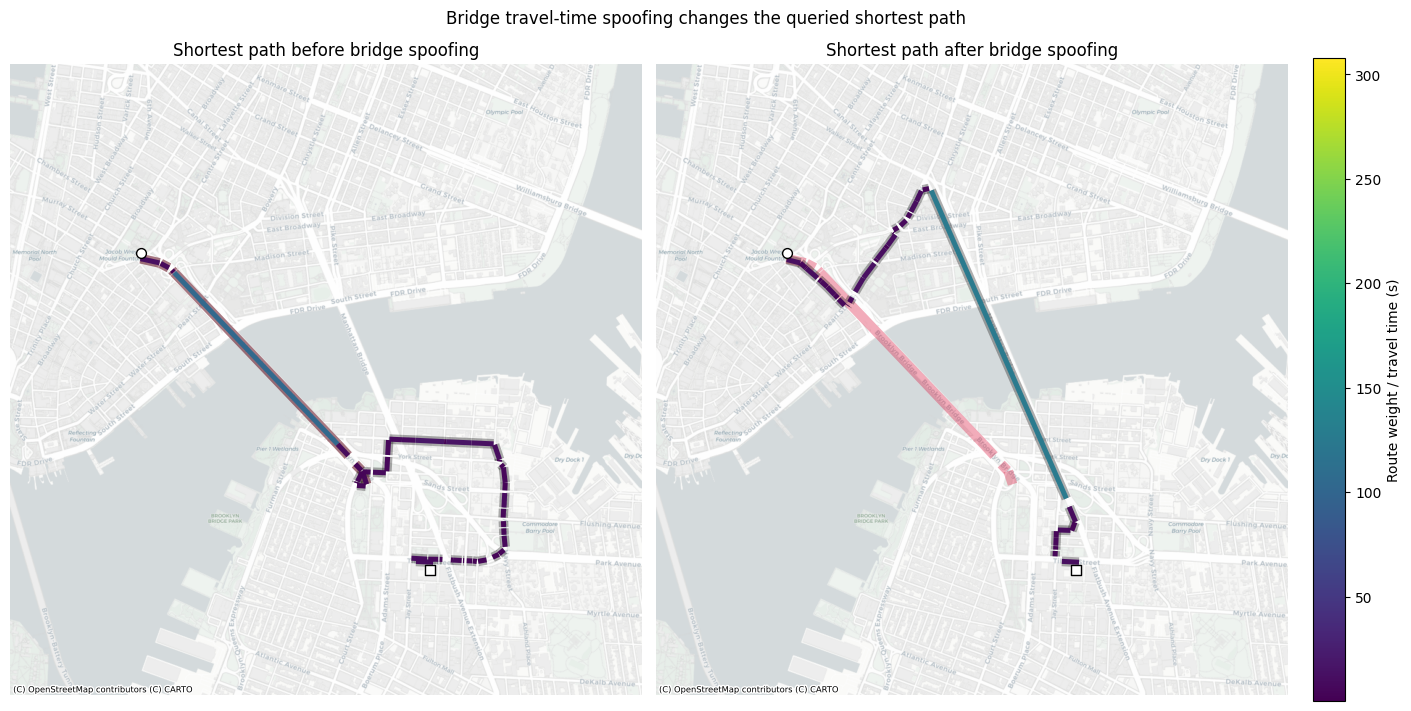

,baseline_route_edges,attacked_route_edges,spoofed_bridge_edges,baseline_uses_spoofed_bridge,attacked_uses_spoofed_bridge,bridge_spoof_multiplier,route_weight_unit,bridge_anchor_distance_m,baseline_route_weight_before_s,attacked_route_weight_after_s
0,44,36,9,True,True,100.0,seconds,780.393215,296.276421,598.337045


In [5]:
route_attack = None
route_attack_summary = None

route_client = None
original_weights = {}

try:
    import contextily as cx
    from matplotlib.collections import LineCollection
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable
    from pyproj import Transformer
except ImportError as exc:
    raise RuntimeError(
        "Attack 4 requires contextily and pyproj for the basemap. Install them with "
        "`pip install contextily pyproj` or rerun from an environment created from requirements.txt."
    ) from exc

try:
    route_config = read_run_config("configs/run_interactive_NYC_blank.json")
    route_sim_dirs = prepare_sim_dirs(route_config)
    run_simulation_in_docker(route_config)

    route_client = METSRClient(
        host=route_config.metsr_host,
        sim_folder=route_sim_dirs[0],
        port=route_config.ports[0] if hasattr(route_config, "ports") else route_config.metsr_port,
        timeout=900,
    )

    origin_lonlat = (-74.0058, 40.7123)      # Lower Manhattan / City Hall area
    destination_lonlat = (-73.9857, 40.6956) # Downtown Brooklyn
    bridge_anchor_lonlat = (-73.9969, 40.7061) # Brooklyn Bridge crossing reference
    bridge_window_radius = 4
    bridge_spoof_multiplier = 100.0
    route_weight_unit = "seconds"

    wgs84_to_mercator = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

    def lonlat_to_web_mercator(lonlat):
        lonlat = np.asarray(lonlat, dtype=float)
        if lonlat.ndim == 1:
            x, y = wgs84_to_mercator.transform(float(lonlat[0]), float(lonlat[1]))
            return np.asarray([x, y], dtype=float)
        x, y = wgs84_to_mercator.transform(lonlat[:, 0], lonlat[:, 1])
        return np.column_stack([x, y])

    def road_id_from_row(row, default=None):
        if not isinstance(row, dict):
            return default
        return row.get("ID", row.get("roadID", row.get("orig_id", default)))

    def weight_from_row(row):
        value = row.get("weight", row.get("avg_travel_time")) if isinstance(row, dict) else None
        return None if value is None else float(value)

    def centerline_array(row):
        centerline = np.asarray(row.get("centerline", []), dtype=float)
        if centerline.ndim != 2 or centerline.shape[0] < 2 or centerline.shape[1] < 2:
            return None
        return centerline[:, :2]

    def looks_like_lonlat(xy):
        return bool(
            np.isfinite(xy).all()
            and np.nanmin(xy[:, 0]) >= -180.0
            and np.nanmax(xy[:, 0]) <= 180.0
            and np.nanmin(xy[:, 1]) >= -90.0
            and np.nanmax(xy[:, 1]) <= 90.0
        )

    def native_wgs84_lonlat(row):
        xy = centerline_array(row)
        if xy is None:
            return None
        if looks_like_lonlat(xy):
            lonlat = xy
        elif looks_like_lonlat(xy[:, ::-1]):
            lonlat = xy[:, ::-1]
        else:
            return None
        lon_mid = float(np.nanmedian(lonlat[:, 0]))
        lat_mid = float(np.nanmedian(lonlat[:, 1]))
        if not (-75.5 <= lon_mid <= -72.0 and 39.0 <= lat_mid <= 42.0):
            return None
        return lonlat

    def route_road_list(response):
        rows = response.get("DATA", []) if isinstance(response, dict) else []
        if not rows:
            return []
        row = rows[0]
        if row == "KO" or row is None:
            return []
        if isinstance(row, dict):
            roads = row.get("road_list", row.get("roadList", row.get("roads", [])))
            return list(roads or [])
        if isinstance(row, list):
            return list(row)
        return []

    def query_shortest_route():
        response = route_client.query_route(
            origin_lonlat[0],
            origin_lonlat[1],
            destination_lonlat[0],
            destination_lonlat[1],
            transform_coords=False,
        )
        roads = route_road_list(response)
        if not roads:
            raise RuntimeError(f"No route was returned for the bridge-spoofing OD pair: {response}")
        return roads, response

    def query_weight_map(road_ids):
        rows = route_client.query_road_weights(list(road_ids)).get("DATA", []) if road_ids else []
        weights = {}
        for row in rows:
            road_id = road_id_from_row(row)
            weight = weight_from_row(row)
            if road_id is not None and weight is not None:
                weights[road_id] = weight
        return weights

    def query_centerline_map(road_ids):
        rows = route_client.query_centerline(list(road_ids), transform_coords=False).get("DATA", []) if road_ids else []
        centerlines = {}
        rejected = 0
        for requested_id, row in zip(road_ids, rows):
            road_id = road_id_from_row(row, requested_id)
            lonlat = native_wgs84_lonlat(row)
            if road_id is None or lonlat is None:
                rejected += 1
                continue
            mercator = lonlat_to_web_mercator(lonlat)
            if np.isfinite(mercator).all():
                centerlines[road_id] = {"lonlat": lonlat, "mercator": mercator}
            else:
                rejected += 1
        return centerlines, rejected

    def route_segments(route_roads, centerline_map):
        segments = []
        road_ids = []
        for road_id in route_roads:
            row = centerline_map.get(road_id)
            if row is None:
                continue
            segments.append(row["mercator"])
            road_ids.append(road_id)
        return segments, road_ids

    def route_values(road_ids, weights):
        return np.asarray([weights.get(road_id, np.nan) for road_id in road_ids], dtype=float)

    baseline_route, baseline_route_response = query_shortest_route()
    baseline_weights = query_weight_map(baseline_route)
    baseline_centerlines, rejected_baseline_centerlines = query_centerline_map(baseline_route)
    baseline_segments, baseline_plot_ids = route_segments(baseline_route, baseline_centerlines)
    if not baseline_segments:
        raise RuntimeError("The baseline route had no plottable WGS84 centerlines.")

    bridge_anchor_xy = lonlat_to_web_mercator(bridge_anchor_lonlat)
    route_distances = []
    for index, road_id in enumerate(baseline_route):
        row = baseline_centerlines.get(road_id)
        if row is None:
            route_distances.append(np.inf)
            continue
        distance = np.nanmin(np.linalg.norm(row["mercator"] - bridge_anchor_xy, axis=1))
        route_distances.append(distance)
    bridge_index = int(np.nanargmin(route_distances))
    bridge_distance_m = float(route_distances[bridge_index])
    start_index = max(0, bridge_index - bridge_window_radius)
    end_index = min(len(baseline_route), bridge_index + bridge_window_radius + 1)
    bridge_road_ids = list(dict.fromkeys(baseline_route[start_index:end_index]))

    original_weights = query_weight_map(bridge_road_ids)
    if not original_weights:
        raise RuntimeError("No bridge-edge weights were returned for the selected crossing segment.")

    spoofed_weights = {road_id: max(1.0, weight * bridge_spoof_multiplier) for road_id, weight in original_weights.items()}
    route_client.update_road_weights(list(spoofed_weights), list(spoofed_weights.values()))

    attacked_route, attacked_route_response = query_shortest_route()
    comparison_road_ids = list(dict.fromkeys(baseline_route + attacked_route + bridge_road_ids))
    attacked_weights = query_weight_map(comparison_road_ids)
    comparison_centerlines, rejected_comparison_centerlines = query_centerline_map(comparison_road_ids)

    route_client.update_road_weights(list(original_weights), list(original_weights.values()))
    restored_weights = query_weight_map(bridge_road_ids)

    attacked_segments, attacked_plot_ids = route_segments(attacked_route, comparison_centerlines)
    bridge_segments, bridge_plot_ids = route_segments(bridge_road_ids, comparison_centerlines)
    baseline_segments, baseline_plot_ids = route_segments(baseline_route, comparison_centerlines)
    if not attacked_segments:
        raise RuntimeError("The attacked route had no plottable WGS84 centerlines.")

    route_attack = {
        "origin_lonlat": origin_lonlat,
        "destination_lonlat": destination_lonlat,
        "bridge_anchor_lonlat": bridge_anchor_lonlat,
        "bridge_distance_m": bridge_distance_m,
        "bridge_spoof_multiplier": bridge_spoof_multiplier,
        "route_weight_unit": route_weight_unit,
        "baseline_route": baseline_route,
        "attacked_route": attacked_route,
        "bridge_road_ids": bridge_road_ids,
        "original_bridge_weights": original_weights,
        "attacked_weights": attacked_weights,
        "restored_bridge_weights": restored_weights,
        "baseline_uses_bridge": bool(set(baseline_route) & set(bridge_road_ids)),
        "attacked_uses_bridge": bool(set(attacked_route) & set(bridge_road_ids)),
        "rejected_centerlines": rejected_baseline_centerlines + rejected_comparison_centerlines,
        "baseline_response": baseline_route_response,
        "attacked_response": attacked_route_response,
        "centerlines": {
            road_id: {
                "lonlat": row["lonlat"].tolist(),
                "mercator": row["mercator"].tolist(),
            }
            for road_id, row in comparison_centerlines.items()
        },
    }
finally:
    if route_client is not None:
        if original_weights:
            try:
                route_client.update_road_weights(list(original_weights), list(original_weights.values()))
            except Exception:
                pass
        route_client.terminate()

if route_attack:
    centerlines = {
        road_id: {
            "mercator": np.asarray(row["mercator"], dtype=float),
            "lonlat": np.asarray(row["lonlat"], dtype=float),
        }
        for road_id, row in route_attack["centerlines"].items()
    }

    def segments_for(road_ids):
        segments = []
        plotted_ids = []
        for road_id in road_ids:
            row = centerlines.get(road_id)
            if row is None:
                continue
            segments.append(row["mercator"])
            plotted_ids.append(road_id)
        return segments, plotted_ids

    baseline_segments, baseline_plot_ids = segments_for(route_attack["baseline_route"])
    attacked_segments, attacked_plot_ids = segments_for(route_attack["attacked_route"])
    bridge_segments, bridge_plot_ids = segments_for(route_attack["bridge_road_ids"])
    all_segments = baseline_segments + attacked_segments + bridge_segments
    if not all_segments:
        raise RuntimeError("No route segments were available to plot for bridge travel-time spoofing.")

    all_xy = np.vstack(all_segments)
    min_x, min_y = np.nanmin(all_xy, axis=0)
    max_x, max_y = np.nanmax(all_xy, axis=0)
    pad_x = max((max_x - min_x) * 0.20, 350.0)
    pad_y = max((max_y - min_y) * 0.20, 350.0)

    # Reconstruct plotting values without querying: baseline uses original weights except bridge roads;
    # attacked uses the spoofed weights already captured in route_attack["attacked_weights"].
    before_weight_map = dict(route_attack["attacked_weights"])
    before_weight_map.update(route_attack["original_bridge_weights"])
    after_weight_map = dict(route_attack["attacked_weights"])
    before_values = route_values(baseline_plot_ids, before_weight_map)
    after_values = route_values(attacked_plot_ids, after_weight_map)
    finite_values = np.concatenate([before_values[np.isfinite(before_values)], after_values[np.isfinite(after_values)]])
    if finite_values.size == 0:
        finite_values = np.asarray([0.0, 1.0])
    norm = Normalize(vmin=float(finite_values.min()), vmax=float(finite_values.max()))
    cmap = plt.get_cmap("viridis")

    fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True, constrained_layout=True)
    panels = [
        (axes[0], "Shortest path before bridge spoofing", baseline_segments, baseline_plot_ids, before_values),
        (axes[1], "Shortest path after bridge spoofing", attacked_segments, attacked_plot_ids, after_values),
    ]

    for ax, title, route_segments_panel, route_ids_panel, values in panels:
        ax.set_xlim(min_x - pad_x, max_x + pad_x)
        ax.set_ylim(min_y - pad_y, max_y + pad_y)
        try:
            cx.add_basemap(
                ax,
                source=cx.providers.CartoDB.Positron,
                attribution_size=6,
                reset_extent=False,
                zorder=0,
            )
        except Exception as exc:
            ax.text(
                0.02,
                0.02,
                f"Basemap unavailable: {exc}",
                transform=ax.transAxes,
                fontsize=8,
                color="0.25",
                bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.7"},
                zorder=5,
            )

        if bridge_segments:
            ax.add_collection(LineCollection(bridge_segments, colors="crimson", linewidths=7.0, alpha=0.35, zorder=2))
        ax.add_collection(LineCollection(route_segments_panel, colors="0.10", linewidths=7.0, alpha=0.35, zorder=3))
        ax.add_collection(LineCollection(route_segments_panel, cmap=cmap, norm=norm, array=values, linewidths=3.6, alpha=0.98, zorder=4))
        ax.scatter(*lonlat_to_web_mercator(route_attack["origin_lonlat"]), marker="o", s=50, color="white", edgecolor="black", zorder=5)
        ax.scatter(*lonlat_to_web_mercator(route_attack["destination_lonlat"]), marker="s", s=50, color="white", edgecolor="black", zorder=5)
        ax.set_title(title)
        ax.set_aspect("equal", adjustable="box")
        ax.set_axis_off()

    scalar_mappable = ScalarMappable(norm=norm, cmap=cmap)
    scalar_mappable.set_array([])
    colorbar = fig.colorbar(scalar_mappable, ax=axes, fraction=0.035, pad=0.02)
    colorbar.set_label("Route weight / travel time (s)")
    plt.suptitle("Bridge travel-time spoofing changes the queried shortest path")
    plt.show()

    baseline_total_before = float(np.nansum(before_values))
    attacked_total_after = float(np.nansum(after_values))
    route_attack_summary = pd.DataFrame([{
        "baseline_route_edges": len(route_attack["baseline_route"]),
        "attacked_route_edges": len(route_attack["attacked_route"]),
        "spoofed_bridge_edges": len(route_attack["bridge_road_ids"]),
        "baseline_uses_spoofed_bridge": route_attack["baseline_uses_bridge"],
        "attacked_uses_spoofed_bridge": route_attack["attacked_uses_bridge"],
        "bridge_spoof_multiplier": route_attack["bridge_spoof_multiplier"],
        "route_weight_unit": route_attack["route_weight_unit"],
        "bridge_anchor_distance_m": route_attack["bridge_distance_m"],
        "baseline_route_weight_before_s": baseline_total_before,
        "attacked_route_weight_after_s": attacked_total_after,
    }])

route_attack_summary if route_attack else None


# Attack 5: Charging-Price Spoofing

This attack uses an explicit EV charging-station choice model so the effect of the spoofed price is visible in taxi destinations. The cell creates two nearby charging stations, computes a synthetic multinomial-logit utility for each L2 station from price, distance, and available ports, samples taxi station assignments from those probabilities, then calls `go_charging(..., cs_id=<station>)` to force the chosen charging destination. After the spoofed price update, it recomputes the probabilities and repeats the controlled charging dispatch.


In [ ]:
import math
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

charging_attack = None

charging_client = None
station_ids_to_restore = []
original_station_prices = {}

utility_model = {
    "name": "synthetic_l2_station_logit",
    "formula": "U_i = beta_price * price_i + beta_distance * distance_i_m + beta_availability * log1p(available_l2_i)",
    "coefficients": {
        "beta_price": -6.0,
        "beta_distance": -0.0015,
        "beta_availability": 0.08,
    },
    "choice_rule": "P_i = exp(U_i) / sum_j exp(U_j)",
    "note": "This is an external controller model for the tutorial; go_charging is called with explicit cs_id values so taxi destinations follow this synthetic EV utility rather than METS-R's public-taxi nearest-station branch.",
}

def station_price(row, charger_type=0):
    if charger_type == 0:
        keys = ("l2_price", "priceL2")
    elif charger_type == 1:
        keys = ("dcfc_price", "l3_price", "priceL3")
    else:
        return np.inf
    for key in keys:
        value = row.get(key)
        if value is not None:
            return float(value)
    return np.inf

def station_capacity(row, charger_type=0):
    if charger_type == 0:
        total = row.get("l2_charger", row.get("num_l2", row.get("numL2")))
        available = row.get("num_available_l2", row.get("available_l2", row.get("l2_available")))
    elif charger_type == 1:
        total = row.get("dcfc_charger", row.get("l3_charger", row.get("num_l3", row.get("numL3"))))
        available = row.get("num_available_dcfc", row.get("num_available_l3", row.get("available_l3")))
    else:
        total = row.get("bus_charger", row.get("num_bus", row.get("numBus")))
        available = row.get("num_available_bus", row.get("available_bus"))
    total = 0 if total is None else int(total)
    available = total if available is None else int(available)
    return total, available

def euclidean_distance_m(x1, y1, x2, y2):
    values = [x1, y1, x2, y2]
    if any(value is None for value in values):
        return np.nan
    return float(math.hypot(float(x1) - float(x2), float(y1) - float(y2)))

def synthetic_ev_station_choice(station_rows, origin_x, origin_y, charger_type=0, coefficients=None):
    coefficients = coefficients or utility_model["coefficients"]
    records = []
    for row in station_rows:
        station_id = row.get("ID", row.get("id"))
        if station_id is None:
            continue
        total_ports, available_ports = station_capacity(row, charger_type)
        price = station_price(row, charger_type)
        distance_m = euclidean_distance_m(origin_x, origin_y, row.get("x"), row.get("y"))
        usable = total_ports > 0 and np.isfinite(price) and np.isfinite(distance_m)
        if usable:
            utility = (
                coefficients["beta_price"] * price
                + coefficients["beta_distance"] * distance_m
                + coefficients["beta_availability"] * math.log1p(max(available_ports, 0))
            )
        else:
            utility = -np.inf
        records.append({
            "station_id": int(station_id),
            "price": price,
            "distance_m": distance_m,
            "total_l2": total_ports,
            "available_l2": available_ports,
            "utility": utility,
            "usable": usable,
        })
    if not records:
        raise RuntimeError("No charging stations available for the synthetic utility model.")

    utilities = np.array([record["utility"] for record in records], dtype=float)
    finite_mask = np.isfinite(utilities)
    probabilities = np.zeros(len(records), dtype=float)
    if finite_mask.any():
        stabilized = utilities[finite_mask] - np.max(utilities[finite_mask])
        exp_u = np.exp(stabilized)
        probabilities[finite_mask] = exp_u / exp_u.sum()
    for record, probability in zip(records, probabilities):
        record["probability"] = float(probability)
    return pd.DataFrame(records).sort_values("station_id").reset_index(drop=True)

def extract_vehicle_ids(response):
    vehicle_ids = []
    for row in response.get("DATA", []):
        for key in ("IDs", "ids", "vehIDs", "vehIds"):
            if isinstance(row.get(key), list):
                vehicle_ids.extend(row[key])
        single_id = row.get("ID", row.get("id", row.get("vehID", row.get("vehId"))))
        if single_id is not None:
            vehicle_ids.append(single_id)
    return [int(vehicle_id) for vehicle_id in vehicle_ids]

def assign_taxis_from_probabilities(taxi_ids, probability_df, seed):
    rng = np.random.default_rng(seed)
    station_ids = probability_df["station_id"].to_numpy(dtype=int)
    probabilities = probability_df["probability"].to_numpy(dtype=float)
    if probabilities.sum() <= 0:
        raise RuntimeError("Synthetic utility model assigned zero probability to all stations.")
    probabilities = probabilities / probabilities.sum()
    sampled_station_ids = rng.choice(station_ids, size=len(taxi_ids), p=probabilities)
    assignments = defaultdict(list)
    for taxi_id, station_id in zip(taxi_ids, sampled_station_ids):
        assignments[int(station_id)].append(int(taxi_id))
    return dict(assignments)

def send_taxis_to_assigned_stations(client, assignments, charger_type=0):
    for station_id, taxi_ids in sorted(assignments.items()):
        if taxi_ids:
            client.go_charging(taxi_ids, veh_type=False, charger_type=charger_type, cs_id=int(station_id))

def station_assignment_counts(assignments):
    return {station_id: len(taxi_ids) for station_id, taxi_ids in assignments.items()}

def query_taxi_destinations(client, taxi_ids):
    taxi_rows = client.query_taxi(taxi_ids).get("DATA", [])
    return Counter(row.get("dest") for row in taxi_rows if row.get("dest") is not None), taxi_rows

try:
    charging_config = read_run_config("configs/run_interactive_NYC_blank.json")
    charging_config.name = "Security_ChargingPriceSpoofing"
    charging_config.num_etaxi = 0
    charging_config.dispatching_controlled_by_control_apis = True
    charging_config.repositioning_controlled_by_control_apis = True
    charging_config.charging_controlled_by_control_apis = True

    charging_sim_dirs = prepare_sim_dirs(charging_config)
    run_simulation_in_docker(charging_config)

    charging_client = METSRClient(
        host=charging_config.metsr_host,
        sim_folder=charging_sim_dirs[0],
        port=charging_config.ports[0] if hasattr(charging_config, "ports") else charging_config.metsr_port,
        timeout=900,
    )

    zone_ids = list(charging_client.query_zone().get("id_list", []))
    zone_rows = charging_client.query_zone(zone_ids).get("DATA", [])
    zone_rows = [row for row in zone_rows if row.get("ID") is not None and row.get("x") is not None and row.get("y") is not None]
    if not zone_rows:
        raise RuntimeError("Need at least one zone for the charging-price spoofing experiment.")
    zone_row = sorted(zone_rows, key=lambda row: row.get("veh_stock", 0), reverse=True)[0]
    zone_id = zone_row["ID"]
    origin_x = float(zone_row["x"])
    origin_y = float(zone_row["y"])
    taxi_batch_size = 60
    station_offset = 30.0

    station_response = charging_client.add_charging_station(
        [origin_x, origin_x + station_offset],
        [origin_y, origin_y + station_offset],
        [90, 90],
        [0, 0],
        [0, 0],
        [0.08, 0.60],
        [0.50, 0.50],
    )
    station_rows = station_response.get("DATA", [])
    station_ids = []
    for row in station_rows:
        for key in ("IDs", "ids", "stationIDs", "stationIds"):
            if isinstance(row.get(key), list):
                station_ids.extend(row[key])
        station_id = row.get("ID", row.get("id", row.get("stationID", row.get("stationId"))))
        if station_id is not None:
            station_ids.append(station_id)
    if len(station_ids) < 2:
        station_ids = list(charging_client.query_chargingStation().get("id_list", []))[-2:]
    if len(station_ids) < 2:
        raise RuntimeError("Need two charging stations for the price-spoofing choice experiment.")

    station_a, station_b = [int(station_id) for station_id in station_ids[:2]]
    station_ids_to_restore = [station_a, station_b]
    baseline_stations = charging_client.query_chargingStation([station_a, station_b]).get("DATA", [])
    if len(baseline_stations) < 2:
        raise RuntimeError("Could not query both charging stations for the baseline run.")
    for row in baseline_stations:
        station_id = int(row.get("ID"))
        original_station_prices[station_id] = {
            "l2": station_price(row, 0),
            "dcfc": station_price(row, 1),
        }
    baseline_probability_df = synthetic_ev_station_choice(baseline_stations, origin_x, origin_y, charger_type=0)

    baseline_taxi_response = charging_client.add_taxi(zone_id, taxi_batch_size)
    baseline_taxi_ids = extract_vehicle_ids(baseline_taxi_response)
    if not baseline_taxi_ids:
        available_rows = charging_client.query_available_taxis(zone_id).get("DATA", [])
        baseline_taxi_ids = [int(row.get("ID")) for row in available_rows[:taxi_batch_size] if row.get("ID") is not None]
    if not baseline_taxi_ids:
        raise RuntimeError("No baseline taxis were available for the charging-price spoofing experiment.")

    baseline_assignments = assign_taxis_from_probabilities(baseline_taxi_ids, baseline_probability_df, seed=42)
    send_taxis_to_assigned_stations(charging_client, baseline_assignments, charger_type=0)
    charging_client.tick(max(1, int(round(60 / charging_config.sim_step_size))), wait_forever=True)
    baseline_choices, baseline_taxi_rows = query_taxi_destinations(charging_client, baseline_taxi_ids)
    baseline_after = charging_client.query_chargingStation([station_a, station_b]).get("DATA", [])

    charging_client.update_charging_prices(station_a, 0, 1.50)
    charging_client.update_charging_prices(station_b, 0, 0.04)
    spoofed_prices = charging_client.query_chargingStation([station_a, station_b]).get("DATA", [])
    spoofed_probability_df = synthetic_ev_station_choice(spoofed_prices, origin_x, origin_y, charger_type=0)

    spoofed_taxi_response = charging_client.add_taxi(zone_id, taxi_batch_size)
    spoofed_taxi_ids = extract_vehicle_ids(spoofed_taxi_response)
    if not spoofed_taxi_ids:
        available_rows = charging_client.query_available_taxis(zone_id).get("DATA", [])
        baseline_set = set(baseline_taxi_ids)
        spoofed_taxi_ids = [int(row.get("ID")) for row in available_rows if row.get("ID") not in baseline_set][:taxi_batch_size]
    if not spoofed_taxi_ids:
        raise RuntimeError("No spoofed-run taxis were available for the charging-price spoofing experiment.")

    spoofed_assignments = assign_taxis_from_probabilities(spoofed_taxi_ids, spoofed_probability_df, seed=43)
    send_taxis_to_assigned_stations(charging_client, spoofed_assignments, charger_type=0)
    charging_client.tick(max(1, int(round(60 / charging_config.sim_step_size))), wait_forever=True)
    spoofed_choices, spoofed_taxi_rows = query_taxi_destinations(charging_client, spoofed_taxi_ids)
    spoofed_after = charging_client.query_chargingStation([station_a, station_b]).get("DATA", [])

    for station_id in station_ids_to_restore:
        prices = original_station_prices.get(station_id, {})
        if np.isfinite(prices.get("l2", np.nan)):
            charging_client.update_charging_prices(station_id, 0, prices["l2"])
        if np.isfinite(prices.get("dcfc", np.nan)):
            charging_client.update_charging_prices(station_id, 1, prices["dcfc"])
    restored = charging_client.query_chargingStation([station_a, station_b]).get("DATA", [])

    charging_attack = {
        "zone_id": zone_id,
        "station_ids": [station_a, station_b],
        "utility_model": utility_model,
        "baseline_prices": baseline_stations,
        "baseline_probability_table": baseline_probability_df.to_dict("records"),
        "baseline_assignments": {int(k): list(v) for k, v in baseline_assignments.items()},
        "baseline_assignment_counts": station_assignment_counts(baseline_assignments),
        "baseline_choices": dict(baseline_choices),
        "baseline_after": baseline_after,
        "spoofed_prices": spoofed_prices,
        "spoofed_probability_table": spoofed_probability_df.to_dict("records"),
        "spoofed_assignments": {int(k): list(v) for k, v in spoofed_assignments.items()},
        "spoofed_assignment_counts": station_assignment_counts(spoofed_assignments),
        "spoofed_choices": dict(spoofed_choices),
        "spoofed_after": spoofed_after,
        "restored": restored,
        "choice_shift_detected": bool(
            baseline_choices and spoofed_choices
            and baseline_choices.most_common(1)[0][0] != spoofed_choices.most_common(1)[0][0]
        ),
    }
finally:
    if charging_client is not None:
        for station_id in station_ids_to_restore:
            prices = original_station_prices.get(station_id, {})
            try:
                if np.isfinite(prices.get("l2", np.nan)):
                    charging_client.update_charging_prices(station_id, 0, prices["l2"])
                if np.isfinite(prices.get("dcfc", np.nan)):
                    charging_client.update_charging_prices(station_id, 1, prices["dcfc"])
            except Exception:
                pass
        charging_client.terminate()

if charging_attack:
    station_ids = charging_attack["station_ids"]
    station_labels = [str(station_id) for station_id in station_ids] + ["other"]
    baseline_other = sum(count for dest, count in charging_attack["baseline_choices"].items() if dest not in station_ids)
    spoofed_other = sum(count for dest, count in charging_attack["spoofed_choices"].items() if dest not in station_ids)
    baseline_counts = [charging_attack["baseline_choices"].get(station_id, 0) for station_id in station_ids] + [baseline_other]
    spoofed_counts = [charging_attack["spoofed_choices"].get(station_id, 0) for station_id in station_ids] + [spoofed_other]

    baseline_probability_df = pd.DataFrame(charging_attack["baseline_probability_table"])
    spoofed_probability_df = pd.DataFrame(charging_attack["spoofed_probability_table"])
    baseline_probability = [baseline_probability_df.set_index("station_id").loc[station_id, "probability"] for station_id in station_ids]
    spoofed_probability = [spoofed_probability_df.set_index("station_id").loc[station_id, "probability"] for station_id in station_ids]
    baseline_l2 = [baseline_probability_df.set_index("station_id").loc[station_id, "price"] for station_id in station_ids]
    spoofed_l2 = [spoofed_probability_df.set_index("station_id").loc[station_id, "price"] for station_id in station_ids]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    width = 0.36

    probability_x = np.arange(len(station_ids))
    axes[0].bar(probability_x - width / 2, baseline_probability, width, label="Baseline", color="tab:blue")
    axes[0].bar(probability_x + width / 2, spoofed_probability, width, label="Spoofed", color="tab:red")
    axes[0].set_xticks(probability_x)
    axes[0].set_xticklabels([str(station_id) for station_id in station_ids])
    axes[0].set_ylim(0, 1.05)
    axes[0].set_xlabel("Charging station ID")
    axes[0].set_ylabel("Synthetic EV selection probability")
    axes[0].set_title("External utility model")
    axes[0].legend(fontsize=8)

    choice_x = np.arange(len(station_labels))
    axes[1].bar(choice_x - width / 2, baseline_counts, width, label="Baseline", color="tab:blue")
    axes[1].bar(choice_x + width / 2, spoofed_counts, width, label="Spoofed", color="tab:red")
    axes[1].set_xticks(choice_x)
    axes[1].set_xticklabels(station_labels)
    axes[1].set_xlabel("Charging station ID")
    axes[1].set_ylabel("Taxis routed to station")
    axes[1].set_title("Destinations after explicit go_charging")
    axes[1].legend(fontsize=8)

    price_x = np.arange(len(station_ids))
    axes[2].bar(price_x - width / 2, baseline_l2, width, label="Baseline", color="tab:blue")
    axes[2].bar(price_x + width / 2, spoofed_l2, width, label="Spoofed", color="tab:red")
    axes[2].set_xticks(price_x)
    axes[2].set_xticklabels([str(station_id) for station_id in station_ids])
    axes[2].set_xlabel("Charging station ID")
    axes[2].set_ylabel("L2 price ($/kWh)")
    axes[2].set_title("Spoofed price input")
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

charging_attack
